In [1]:
import pandas as pd
from xgboost import XGBClassifier
import shap
import numpy
import numpy as np
from numpy import mean, std
import xgboost
from xgboost import XGBClassifier
import seaborn as sns
import scipy
import pandas as pd
import sklearn
import matplotlib
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold,RepeatedStratifiedKFold, StratifiedGroupKFold
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.metrics import roc_auc_score,average_precision_score
from sklearn.metrics import f1_score,accuracy_score
from sklearn.metrics import recall_score
from sklearn.metrics import precision_score
from sklearn.metrics import roc_auc_score,balanced_accuracy_score
from sklearn.metrics import f1_score,accuracy_score
from sklearn.metrics import recall_score,average_precision_score
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score
import matplotlib.cm as cm
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from matplotlib.patches import ConnectionPatch
from sklearn.preprocessing import OneHotEncoder
from sklearn import metrics
from sklearn.model_selection import learning_curve, validation_curve
from sklearn.metrics import  roc_curve, RocCurveDisplay
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import ConfusionMatrixDisplay
import sys
from sklearn.svm import SVC
from xgboost import XGBClassifier
#from imblearn.combine import SMOTEENN
#from imblearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

In [2]:
Train_Cal = pd.read_excel("data.xlsx", sheet_name=0, index_col=0)
Train_Cal=Train_Cal.rename(columns={'Total_microbial_mass':'Mean_Glucose'})


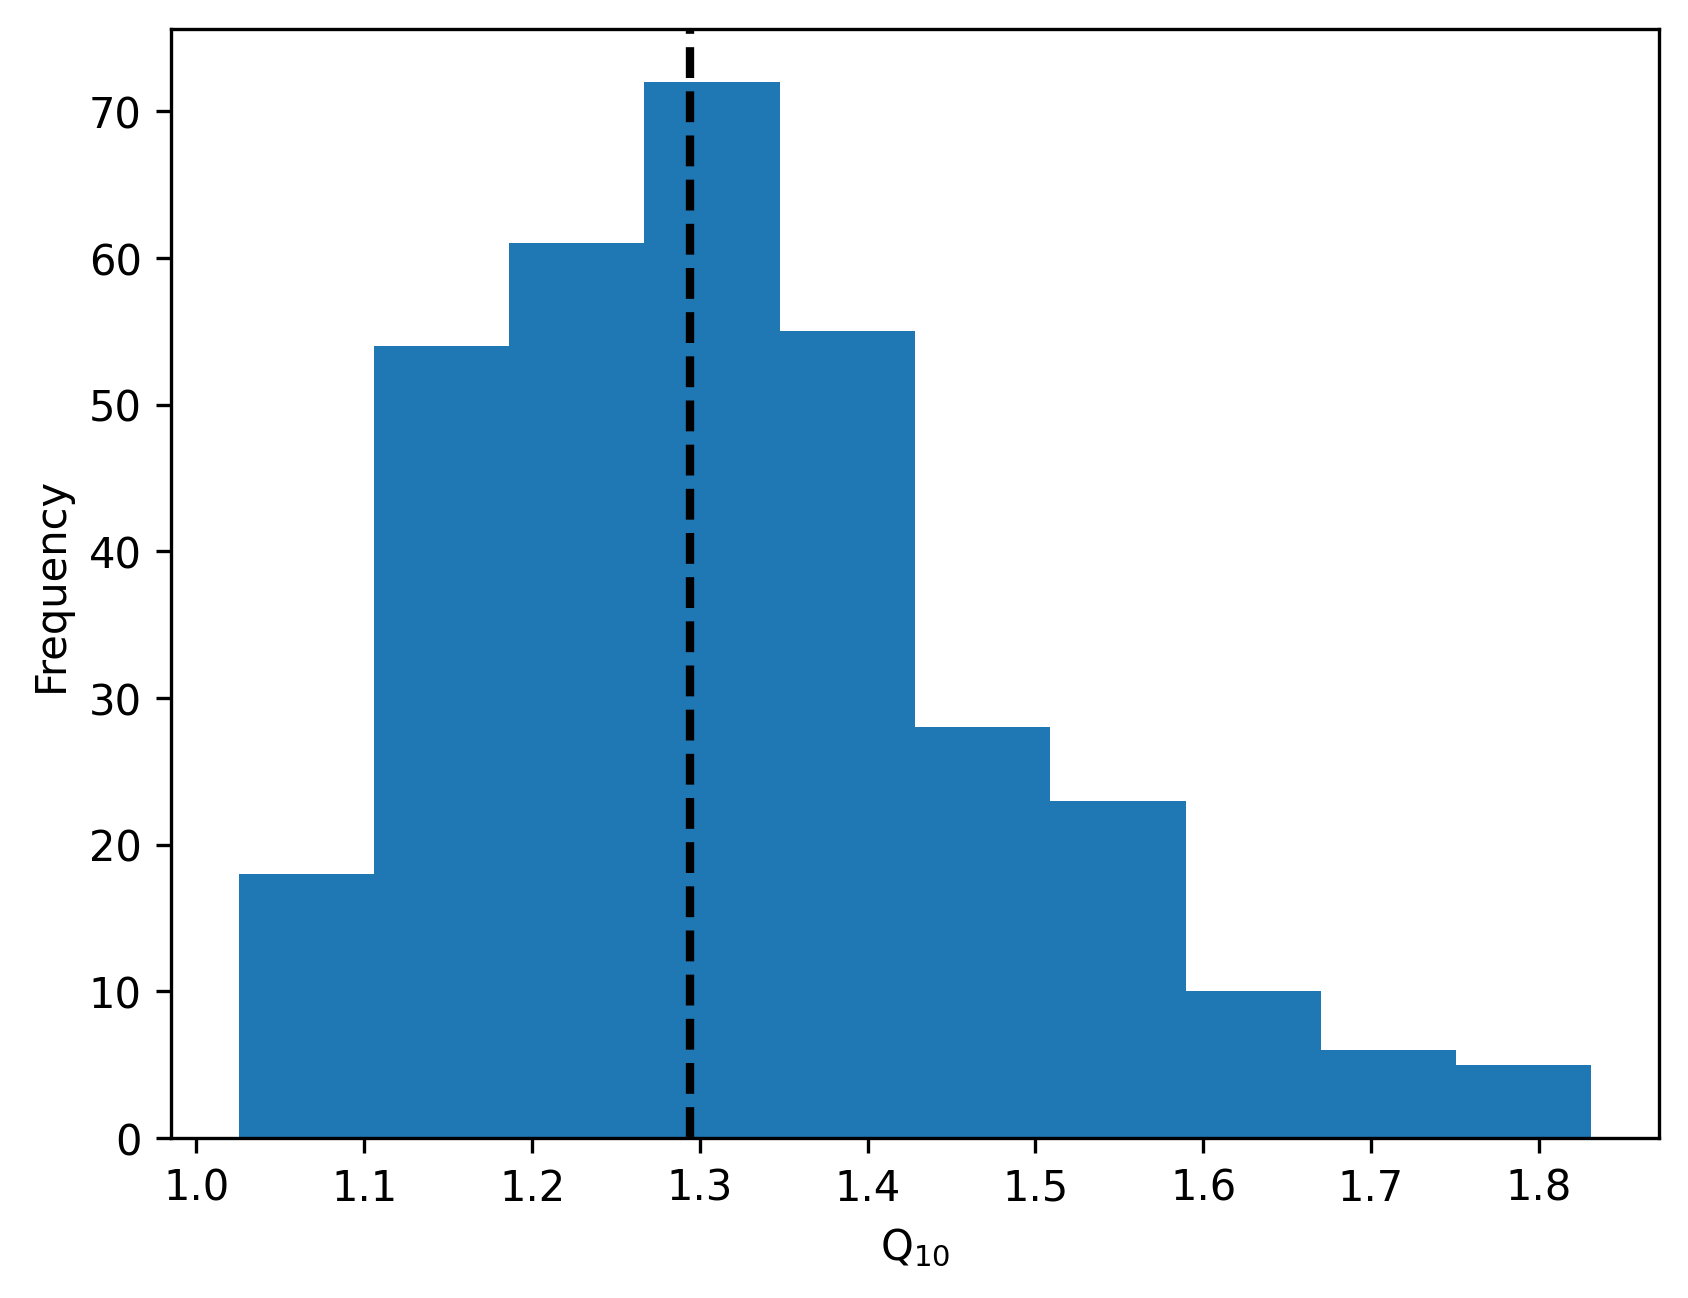

In [3]:
plt.figure(dpi=300)
plt.hist(Train_Cal['Q10_Basal'])
plt.axvline(np.median(Train_Cal['Q10_Basal']), color='k', linestyle='dashed', linewidth=2)
plt.xlabel("Q$_{10}$")
plt.ylabel("Frequency")
plt.show()


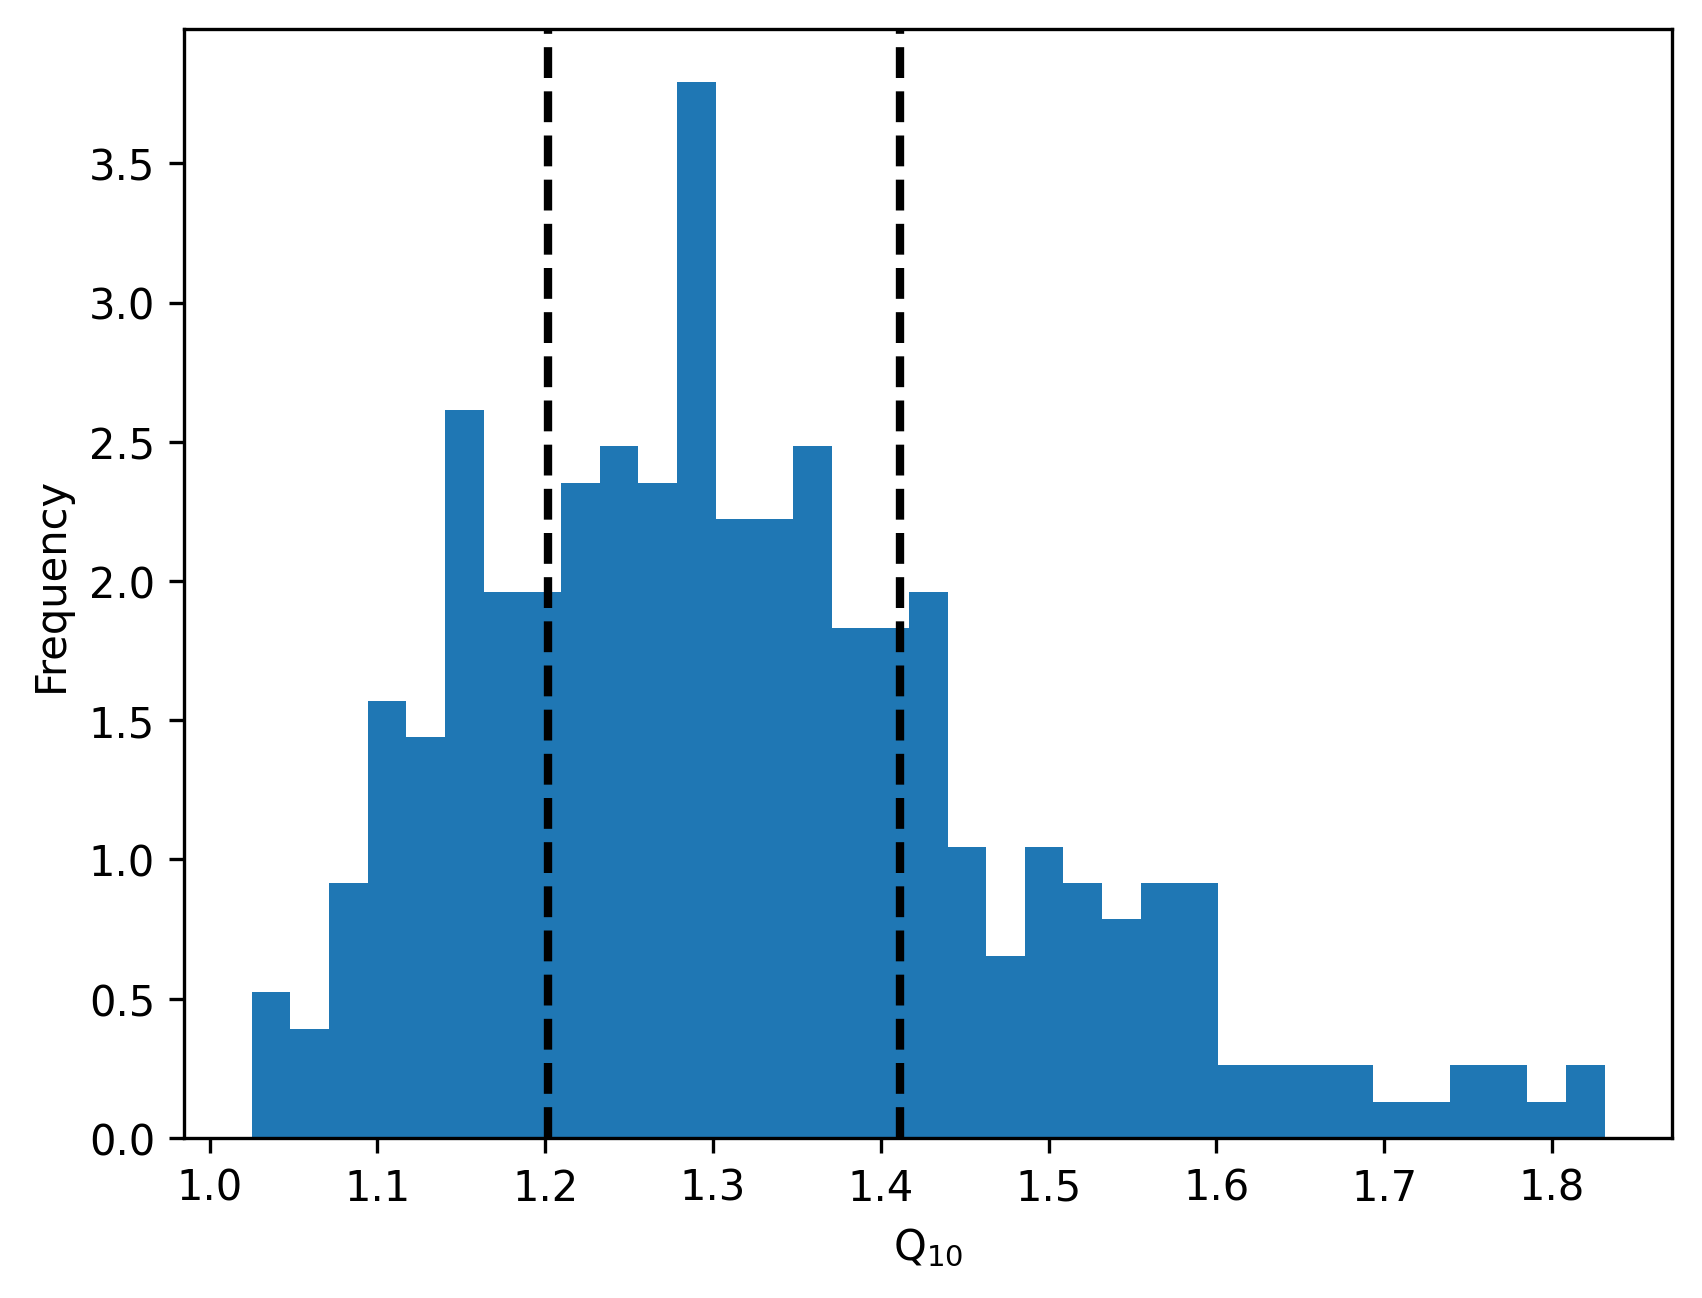

In [4]:
plt.figure(dpi=300)
plt.hist(Train_Cal['Q10_Basal'],bins=35,density=True)
plt.axvline(np.percentile(Train_Cal['Q10_Basal'],75), color='k', linestyle='dashed', linewidth=2)
plt.axvline(np.percentile(Train_Cal['Q10_Basal'],25), color='k', linestyle='dashed', linewidth=2)
plt.xlabel("Q$_{10}$")
plt.ylabel("Frequency")
plt.show()


In [5]:
Train_Cal.columns


Index(['Longitude_c ', 'Forest', 'MAT_wc2', 'MAP_wc2', 'Plant_richness',
       'Plant_cover_v3', 'Soil_pH', 'Soil_salinity', 'Fine_texture', 'Soil_P',
       'Soil_CN', 'SOC', 'MAOC/POC_ratio', 'Aromatic', 'Alkane',
       'Polysaccharide', 'Amide', 'Mean_Glucose', 'Richness_bacteria',
       'Richness_fungi', 'Richness_protist', 'Bacteria_Negative',
       'Fungi_Negative', 'Protists_Negative', 'Bacteria_Positive',
       'Fungi_Positive', 'Protists_Positive', 'POC', 'MAOC', 'Biomass_merged',
       'Bacteria_merged', 'Fungi_merged', 'Q10_Basal'],
      dtype='object')

In [6]:
# Calcola il valore medio della colonna 'peppino'
mean_value = Train_Cal["Q10_Basal"].mean()

# Stampa il valore medio
print("Valore medio della colonna 'q10':", mean_value)


Valore medio della colonna 'q10': 1.3199921539608435


In [7]:
# Definisci una funzione che assegna i valori in base alla condizione
def assign_value(x):
    if x > np.percentile(Train_Cal['Q10_Basal'],75):
        return 1
    else:
        return 0

# Applica la funzione alla colonna 'peppino' utilizzando il metodo apply()
Train_Cal["Q10_Basal_binary"] = Train_Cal["Q10_Basal"].apply(assign_value)



In [8]:
# Conta quanti valori sono uguali a 1 nella colonna 'q10'
count_ones = (Train_Cal["Q10_Basal_binary"] == 0).sum()

# Stampa il numero di valori 1 nella colonna 'q10'
print("Numero di valori 1 nella colonna 'q10':", count_ones)


Numero di valori 1 nella colonna 'q10': 249


In [9]:
df_up=Train_Cal.loc[Train_Cal['Q10_Basal']>np.percentile(Train_Cal['Q10_Basal'],75)]
df_low=Train_Cal.loc[Train_Cal['Q10_Basal']<np.percentile(Train_Cal['Q10_Basal'],25)]
df=pd.concat([df_low,df_up],axis=0)
df


,Longitude_c,Forest,MAT_wc2,MAP_wc2,Plant_richness,Plant_cover_v3,Soil_pH,Soil_salinity,Fine_texture,Soil_P,...,Bacteria_Positive,Fungi_Positive,Protists_Positive,POC,MAOC,Biomass_merged,Bacteria_merged,Fungi_merged,Q10_Basal,Q10_Basal_binary
Sample ID,,,,,,,,,,,,,,,,,,,,,
6,127.442500,1,3.37083,744,41,73.790000,4.47,444.0,75.520000,562.759966,...,0.028901,0.007664,0.000807,47.325914,52.674086,17.624084,14.449036,3.175048,1.068829,0
12,128.237500,1,3.39583,616,59,47.890000,4.81,99.0,69.940000,346.049327,...,0.045724,0.015816,0.024327,36.144560,63.855440,19.297049,16.163066,3.133983,1.068525,0
31,-60.382200,0,-3.53750,509,1,0.830000,7.51,81.0,27.680000,297.976019,...,0.080986,0.025597,0.009175,25.702764,74.297236,3.946542,2.777537,1.169005,1.105205,0
33,-58.469622,0,-2.55000,768,1,2.570000,4.75,134.0,20.120000,4740.692887,...,0.011845,0.020737,0.048246,19.890022,80.109978,6.801914,5.504772,1.297142,1.025126,0
35,-61.102333,0,-2.37500,633,0,0.000000,4.93,85.0,8.100000,1339.262943,...,0.077393,0.059463,0.039131,23.299136,76.700864,8.215138,6.847692,1.367446,1.036250,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1576,-4.412440,0,15.00420,379,13,30.666667,6.35,150.3,14.444444,866.756595,...,0.134721,0.066673,0.028939,44.014358,55.985642,NaN,NaN,NaN,1.425194,1
1578,-4.412140,1,15.00420,379,7,23.333333,6.44,465.0,30.111111,883.748754,...,0.134743,0.031268,0.000807,44.008893,55.991107,NaN,NaN,NaN,1.428781,1
1589,-3.762570,1,12.16670,590,29,38.222222,7.31,353.0,53.333333,505.048990,...,0.161807,0.010563,0.049788,58.429876,41.570124,74.259327,60.540770,13.718556,1.530755,1


In [10]:
test=pd.concat([df,Train_Cal]).drop_duplicates(keep=False)
test_X=test.iloc[:,:-7]
test_y=test.iloc[:,-2]
test_y

Sample ID
41      1.221276
44      1.330410
47      1.234657
59      1.324086
65      1.321266
          ...   
1619    1.292911
1621    1.217639
1622    1.278983
1623    1.234128
1629    1.291360
Name: Q10_Basal, Length: 166, dtype: float64

In [11]:
y = df["Q10_Basal_binary"]
X = df.iloc[:, :-7]


In [14]:
X.columns

Index(['Longitude_c ', 'Forest', 'MAT_wc2', 'MAP_wc2', 'Plant_richness',
       'Plant_cover_v3', 'Soil_pH', 'Soil_salinity', 'Fine_texture', 'Soil_P',
       'Soil_CN', 'SOC', 'MAOC/POC_ratio', 'Aromatic', 'Alkane',
       'Polysaccharide', 'Amide', 'Mean_Glucose', 'Richness_bacteria',
       'Richness_fungi', 'Richness_protist', 'Bacteria_Negative',
       'Fungi_Negative', 'Protists_Negative', 'Bacteria_Positive',
       'Fungi_Positive', 'Protists_Positive'],
      dtype='object')

<Axes: xlabel='Q10_Basal_binary', ylabel='SOC'>

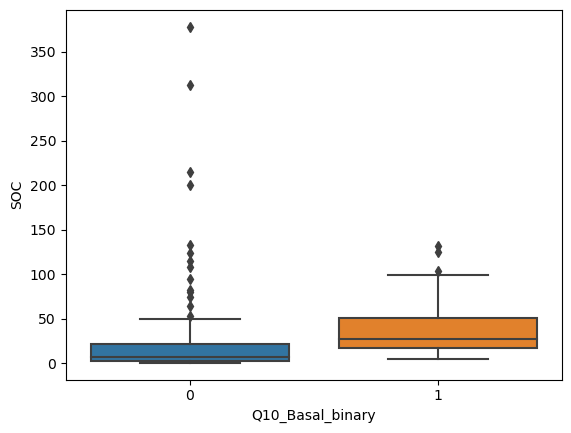

In [32]:
sns.boxplot(data=df, y="SOC", x="Q10_Basal_binary")

<Axes: xlabel='Q10_Basal_binary', ylabel='Alkane'>

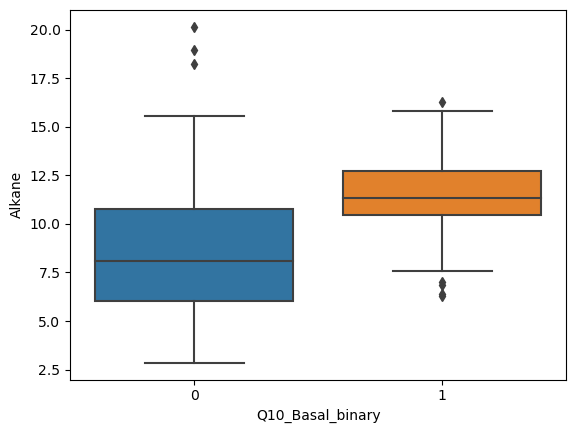

In [30]:
sns.boxplot(data=df, y="Alkane", x="Q10_Basal_binary")

<Axes: xlabel='Q10_Basal_binary', ylabel='Longitude_c '>

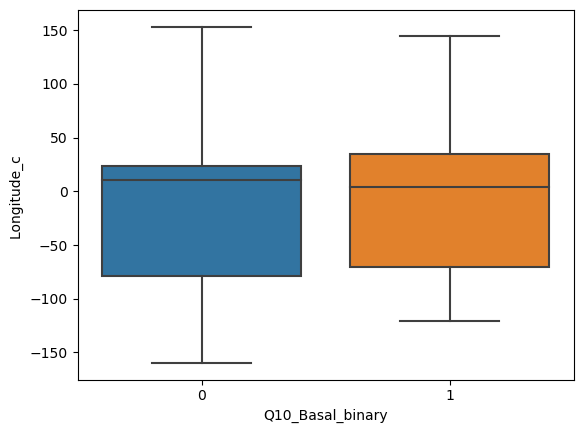

In [26]:
sns.boxplot(data=df, y="Longitude_c ", x="Q10_Basal_binary")

In [126]:
np.unique(y,return_counts=True)


(array([0, 1]), array([83, 83]))

In [128]:
X.columns


Index(['Longitude_c ', 'Forest', 'MAT_wc2', 'MAP_wc2', 'Plant_richness',
       'Plant_cover_v3', 'Soil_pH', 'Soil_salinity', 'Fine_texture', 'Soil_P',
       'Soil_CN', 'SOC', 'MAOC/POC_ratio', 'Aromatic', 'Alkane',
       'Polysaccharide', 'Amide', 'Mean_Glucose', 'Richness_bacteria',
       'Richness_fungi', 'Richness_protist', 'Bacteria_Negative',
       'Fungi_Negative', 'Protists_Negative', 'Bacteria_Positive',
       'Fungi_Positive', 'Protists_Positive'],
      dtype='object')

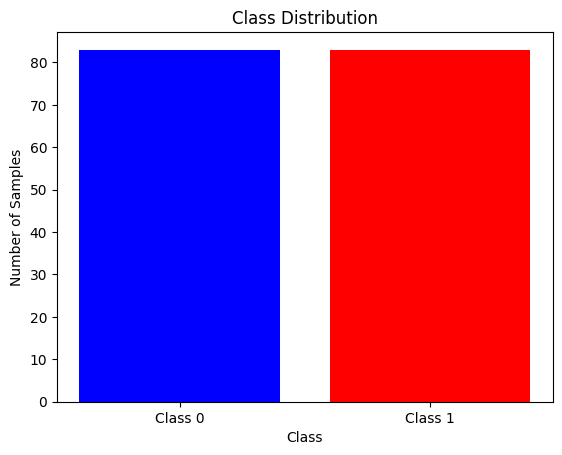

In [12]:
import matplotlib.pyplot as plt

# Conta il numero di campioni per ogni classe
class_counts = [y[y == 0].count(), y[y == 1].count()]

# Etichette per le classi
class_labels = ['Class 0', 'Class 1']

# Crea un grafico a barre per visualizzare la distribuzione delle classi
plt.bar(class_labels, class_counts, color=['blue', 'red'])

# Aggiungi titolo e etichette
plt.title('Class Distribution')
plt.xlabel('Class')
plt.ylabel('Number of Samples')

# Mostra il grafico
plt.show()

In [16]:
np.unique(y,return_counts=True)

(array([0, 1]), array([83, 83]))

In [13]:
np.random.seed(1) # Reproducibility 
CV_repeats = 20
# Make a list of random integers between 0 and 10000 of length = CV_repeats to act as different data splits
random_states = np.random.randint(10000, size=CV_repeats) 

######## Use a dict to track the SHAP values of each observation per CV repitition 

shap_values_per_cv = dict()
for sample in X.index:
    ## Create keys for each sample
    shap_values_per_cv[sample] = {} 
    ## Then, keys for each CV fold within each sample
    for CV_repeat in range(CV_repeats):
        shap_values_per_cv[sample][CV_repeat] = {}

######## Use a dict to track the output probability of each observation per CV repitition   

prob_per_cv = dict()
for sample in test.index:
    ## Create keys for each sample
    prob_per_cv[sample] = {} 
    ## Then, keys for each CV fold within each sample
    for CV_repeat in range(CV_repeats):
        prob_per_cv[sample][CV_repeat] = {}


------------ CV Repeat number: 0

------ Fold Number: 0
Best parameters of the model are:  {'C': 1.0, 'penalty': 'l1', 'solver': 'saga'}

------ Fold Number: 1
Best parameters of the model are:  {'C': 0.5, 'penalty': 'l2', 'solver': 'saga'}

------ Fold Number: 2
Best parameters of the model are:  {'C': 0.5, 'l1_ratio': 0.5, 'penalty': 'elasticnet', 'solver': 'saga'}

------ Fold Number: 3
Best parameters of the model are:  {'C': 1.0, 'penalty': 'l1', 'solver': 'saga'}

------ Fold Number: 4
Best parameters of the model are:  {'C': 0.5, 'penalty': 'l1', 'solver': 'liblinear'}

------ Fold Number: 5
Best parameters of the model are:  {'C': 1.0, 'penalty': 'l1', 'solver': 'liblinear'}

------ Fold Number: 6
Best parameters of the model are:  {'C': 0.5, 'l1_ratio': 0.5, 'penalty': 'elasticnet', 'solver': 'saga'}

------ Fold Number: 7
Best parameters of the model are:  {'C': 1.0, 'penalty': 'l2', 'solver': 'liblinear'}

------ Fold Number: 8
Best parameters of the model are:  {'C': 0.5, 

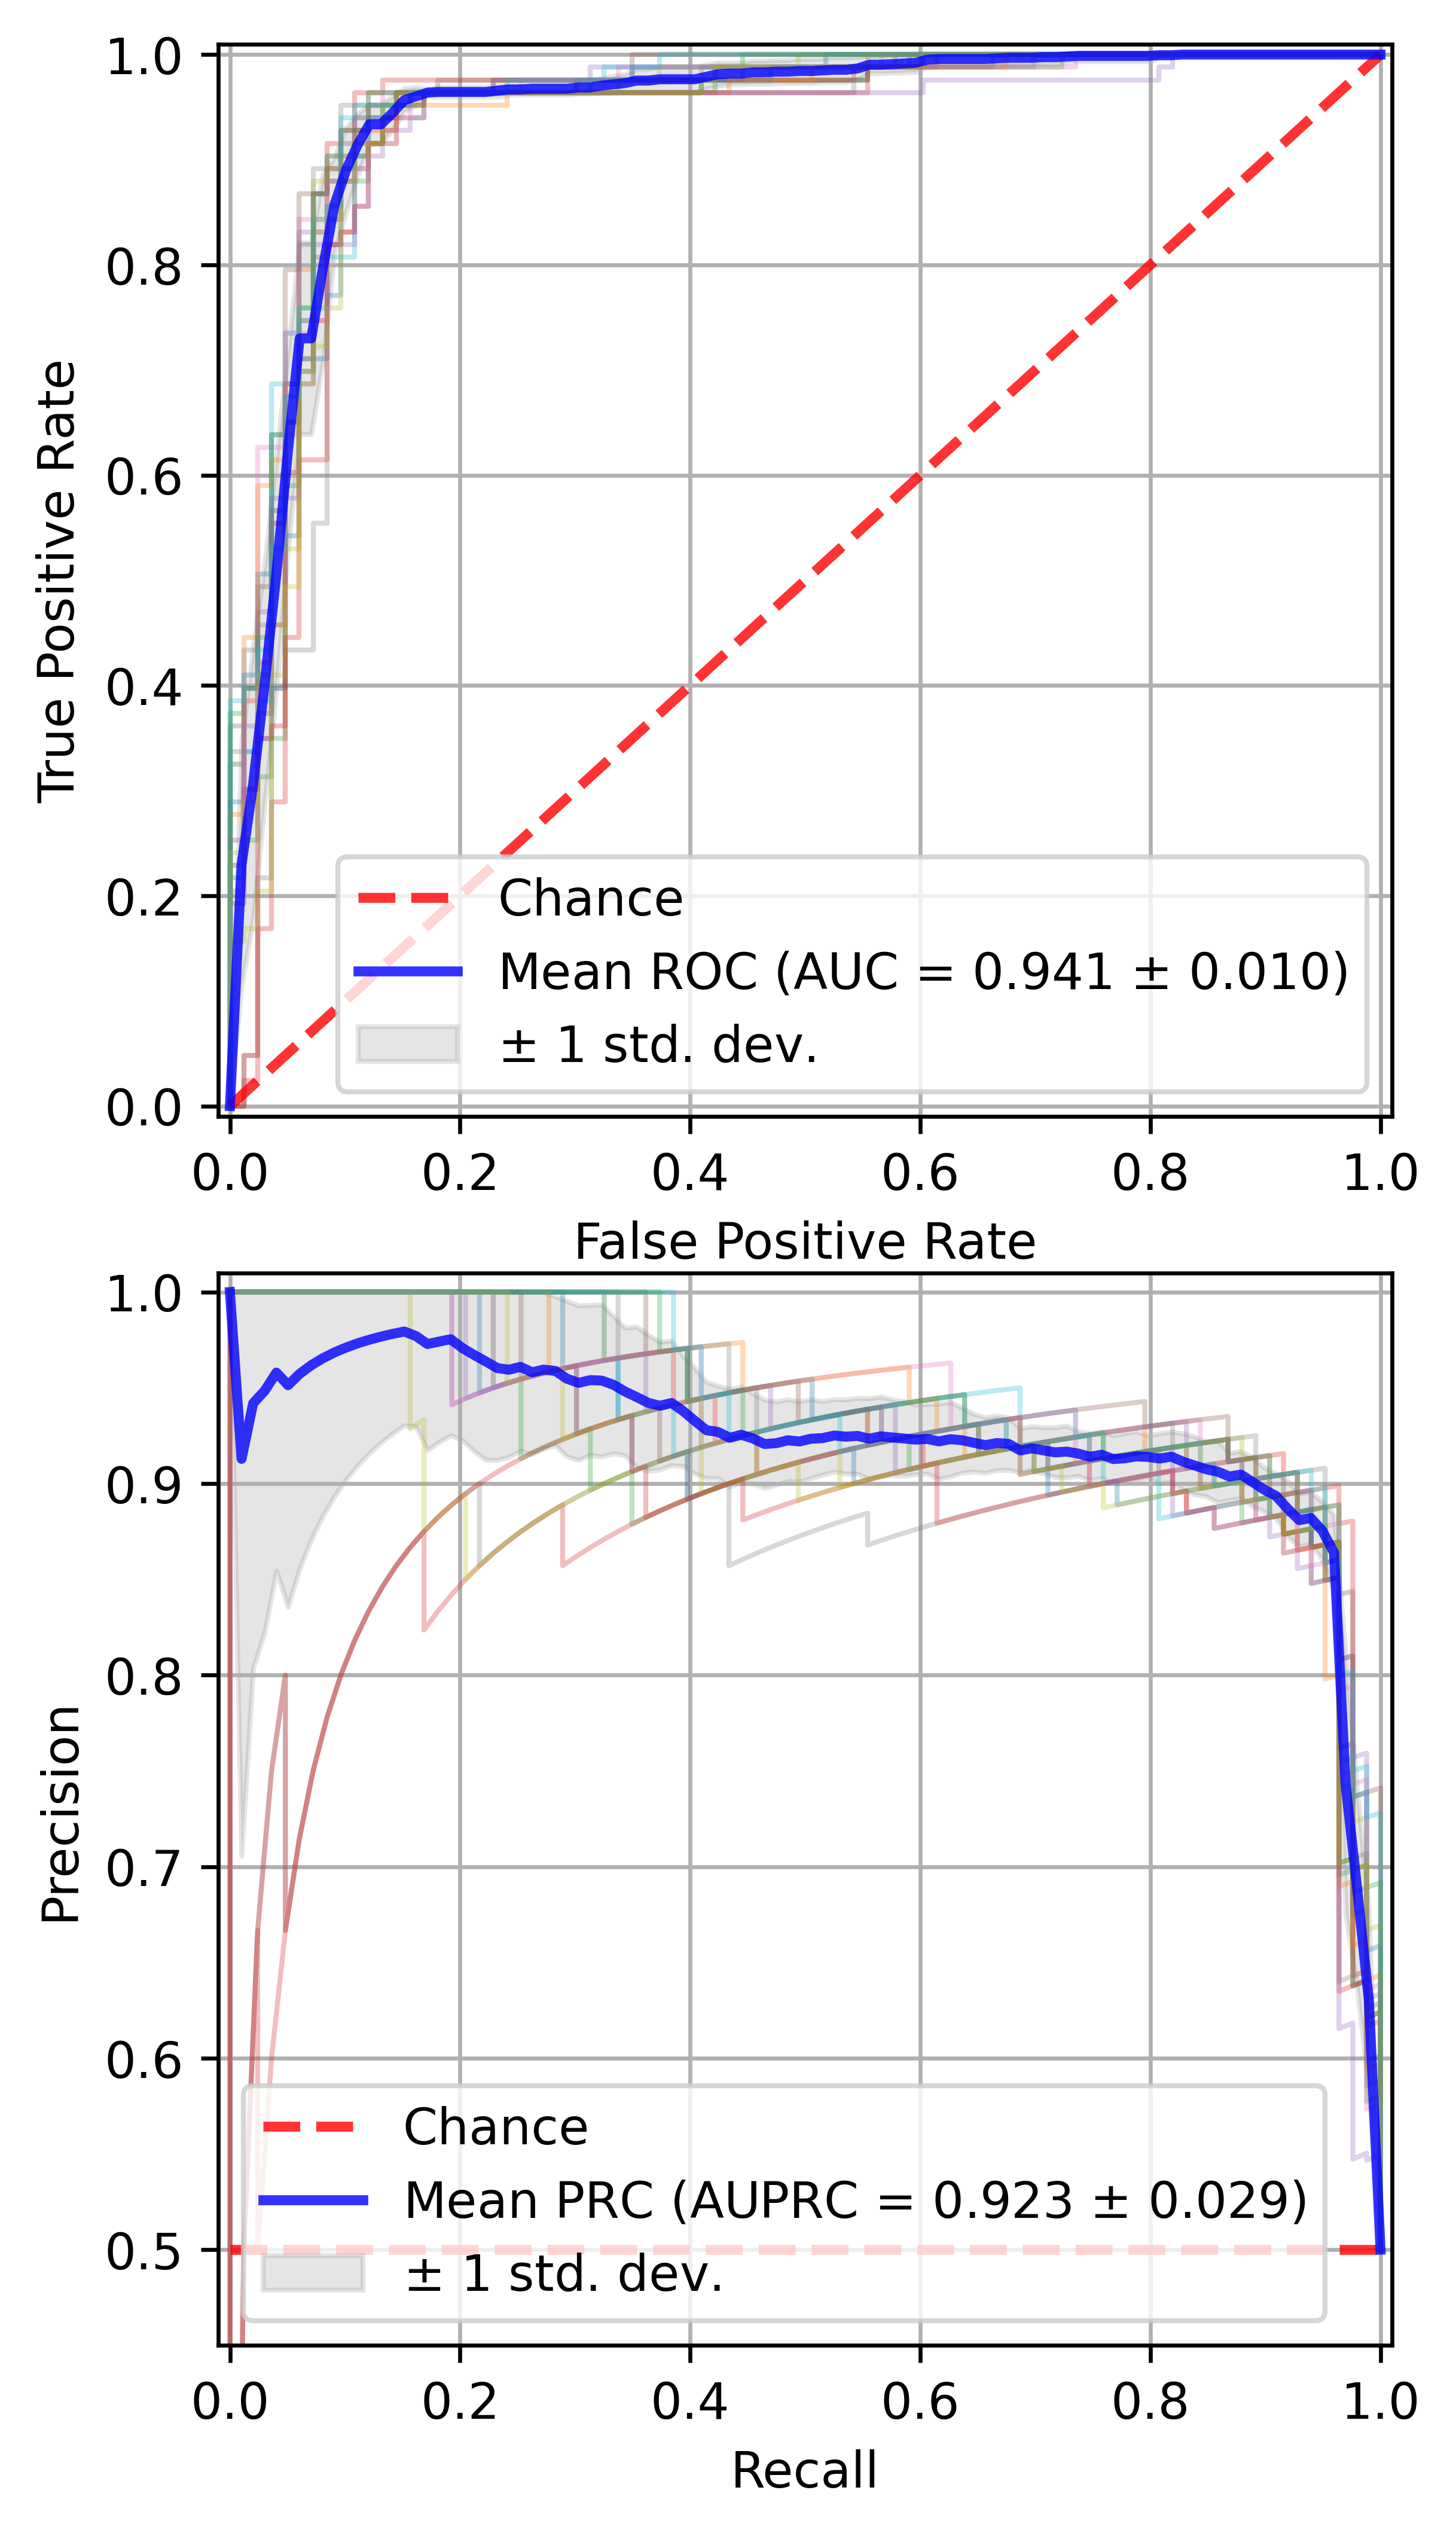

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, f1_score, roc_curve, precision_recall_curve, auc

# Define the parameter grid with compatible solvers
param_grid = [
    {'C': [1.0, 0.1, 0.01, 0.5], 'penalty': ['l1'], 'solver': ['liblinear', 'saga']},
    {'C': [1.0, 0.1, 0.01, 0.5], 'penalty': ['l2'], 'solver': ['lbfgs', 'liblinear', 'saga']},
    {'C': [1.0, 0.1, 0.01, 0.5], 'penalty': ['elasticnet'], 'solver': ['saga'], 'l1_ratio': [0.5]}
]

# Setup the plotting
fig, ax = plt.subplots(nrows=2, ncols=1, dpi=600, figsize=(4, 7))
fig.tight_layout()
ax1, ax2 = ax.flatten()

tprs = []
aucs = []
mean_fpr = np.linspace(0, 1, 100)

precision_array = []
mean_recall_array = np.linspace(0, 1, 100)
aucs_pr = []

importance_xgb = pd.DataFrame(columns=X.columns)
acc_xgb = list()
prec_xgb = list()
f1_xgb = list()

parameters = list()

for CV_repeat in range(CV_repeats):
    print('\n------------ CV Repeat number:', CV_repeat)
    CV = StratifiedKFold(n_splits=10, shuffle=True, random_state=random_states[CV_repeat])
    ix_training, ix_test = [], []

    for fold in CV.split(X, y):
        ix_training.append(fold[0])
        ix_test.append(fold[1])

    predicted = []
    label = []
    score = []

    for i, (train_outer_ix, test_outer_ix) in enumerate(zip(ix_training, ix_test)):
        print('\n------ Fold Number:', i)
        X_train, X_test = X.iloc[train_outer_ix, :], X.iloc[test_outer_ix, :]
        y_train, y_test = y.iloc[train_outer_ix], y.iloc[test_outer_ix]

        cv_inner = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)
        
        scaler = StandardScaler()
        scaler.fit(X_train)
        X_train_scaled = scaler.transform(X_train)
        X_test_scaled = scaler.transform(X_test)
        X_train = pd.DataFrame(X_train_scaled, index=X_train.index, columns=X_train.columns)
        X_test = pd.DataFrame(X_test_scaled, index=X_test.index, columns=X_test.columns)

        model = LogisticRegression(random_state=0, max_iter=10000)

        search = GridSearchCV(model, param_grid, scoring='roc_auc', cv=cv_inner, refit=True)
        result = search.fit(X_train, y_train)

        best_model = result.best_estimator_
        best_param = result.best_params_
        parameters.append(best_param)
        print('Best parameters of the model are: ', best_param)

        best_model.fit(X_train, y_train)

        yhat = best_model.predict(X_test)
        y_score = best_model.predict_proba(X_test)[:, 1]

        label.append(y_test)
        predicted.append(yhat)
        score.append(y_score)

    acc_sc = accuracy_score(np.hstack(label), np.hstack(predicted))
    acc_xgb.append(acc_sc)

    prec_sc = precision_score(np.hstack(label), np.hstack(predicted), pos_label=1)
    prec_xgb.append(prec_sc)

    f1_sc = f1_score(np.hstack(label), np.hstack(predicted))
    f1_xgb.append(f1_sc)

    fpr, tpr, _ = roc_curve(np.hstack(label), np.hstack(score))
    tprs.append(np.interp(mean_fpr, fpr, tpr))
    tprs[-1][0] = 0.0
    roc_auc = auc(fpr, tpr)
    aucs.append(roc_auc)
    ax1.plot(fpr, tpr, lw=1, alpha=0.3)

    precision_fold, recall_fold, _ = precision_recall_curve(np.hstack(label), np.hstack(score))
    precision_fold, recall_fold = precision_fold[::-1], recall_fold[::-1]
    prec_array = np.interp(mean_recall_array, recall_fold, precision_fold)
    precision_array.append(prec_array)
    precision_array[-1][0] = 1
    pr_auc = auc(recall_fold, precision_fold)
    aucs_pr.append(pr_auc)
    ax2.plot(recall_fold, precision_fold, alpha=0.3, lw=1)

ax1.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r', label='Chance', alpha=0.8)
mean_tpr = np.mean(tprs, axis=0)
mean_tpr[-1] = 1.0
mean_auc = auc(mean_fpr, mean_tpr)
std_auc = np.std(aucs)
ax1.plot(mean_fpr, mean_tpr, color='b', label=r'Mean ROC (AUC = %0.3f $\pm$ %0.3f)' % (mean_auc, std_auc), lw=2, alpha=.8)

std_tpr = np.std(tprs, axis=0)
tprs_upper = np.minimum(mean_tpr + std_tpr, 1)
tprs_lower = np.maximum(mean_tpr - std_tpr, 0)
ax1.fill_between(mean_fpr, tprs_lower, tprs_upper, color='grey', alpha=.2, label=r'$\pm$ 1 std. dev.')

ax1.set_xlim([-0.01, 1.01])
ax1.set_ylim([-0.01, 1.01])
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.legend(loc="lower right")
ax1.grid()

no_skill = len(np.hstack(label)[np.hstack(label) == 1]) / len(np.hstack(label))
ax2.plot([0, 1], [no_skill, no_skill], linestyle='--', lw=2, label='Chance', alpha=0.8, color='r')
mean_precision_array = np.mean(precision_array, axis=0)
mean_auc_pr = auc(mean_recall_array, mean_precision_array)
std_auc_pr = np.std(aucs_pr)
ax2.plot(mean_recall_array, mean_precision_array, color='b', label=r'Mean PRC (AUPRC = %0.3f $\pm$ %0.3f)' % (mean_auc_pr, std_auc_pr), lw=2, alpha=0.8)

std_precision_array = np.std(precision_array, axis=0)
precision_array_upper = np.minimum(mean_precision_array + std_precision_array, 1)
precision_array_lower = np.maximum(mean_precision_array - std_precision_array, 0)
ax2.fill_between(mean_recall_array, precision_array_lower, precision_array_upper, color='grey', alpha=0.2, label=r'$\pm$ 1 std. dev.')

ax2.set_xlim([-0.01, 1.01])
ax2.set_ylim([no_skill - 0.05, 1.01])
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.legend(loc='lower left')
ax2.grid()

plt.show()


In [71]:
# Establish lists to keep average prob values, their Stds, and their min and max
average_prob, prob_stds, prob_ranges = [],[],[]

for i in test.index:
    df_per_obs = pd.DataFrame([prob_per_cv[i]]) # Get all prob  values for sample number i
    # Get relevant statistics for every sample 
    average_prob.append(df_per_obs.mean(axis=1).values) 
    prob_stds.append(df_per_obs.std(axis=1).values)
    prob_ranges.append(df_per_obs.max(axis=1).values-df_per_obs.min(axis=1).values)
average_prob=np.hstack(average_prob)

In [73]:
np.corrcoef(test_y.values,average_prob)

array([[1.       , 0.5317782],
       [0.5317782, 1.       ]])

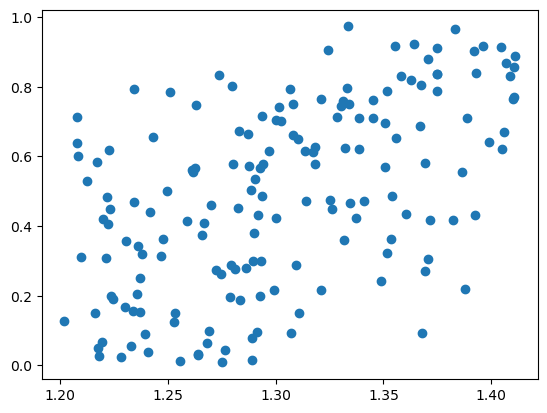

In [91]:
plt.scatter(test_y.values,average_prob)

index=X.columns.get_loc("Bacteria_Negative")
fig, ax =plt.subplots(nrows=1, ncols=1, dpi=300) 
p=ax.scatter(X.iloc[:,index].values, np.array(average_shap_values)[:,index], c=df["Q10_Basal"], s=10,cmap='cividis') # s is a size of marker 
ax.set_ylabel('SHAP value for \n'+ X.columns[index])
ax.set_xlabel(X.columns[index])
fig.colorbar(p,ax=ax,orientation='vertical',label='Q10_Basal')
plt.show()

In [20]:
print('ACC: %.3f (%.3f)' % (mean(acc_xgb), std(acc_xgb)))
print('Precision: %.3f (%.3f)' % (mean(prec_xgb), std(prec_xgb)))
print('AuROC: %.3f (%.3f)' % (mean_auc, std_auc))
print('F1: %.3f (%.3f)' % (mean(f1_xgb), std(f1_xgb)))
print('AuPRC: %.3f (%.3f)' % (mean_auc_pr, std_auc_pr))

ACC: 0.901 (0.010)
Precision: 0.892 (0.014)
AuROC: 0.941 (0.010)
F1: 0.902 (0.010)
AuPRC: 0.923 (0.029)


In [79]:
# Melted data i.e., long format
df_importance_xgb = pd.melt(importance_xgb,var_name='feature name', value_name='coef. of importance')
grouped_xgb= df_importance_xgb.loc[:,['feature name', 'coef. of importance']] \
    .groupby(['feature name']) \
    .median() \
    .sort_values(by='coef. of importance',ascending=False)

Text(0, 0.5, 'Feature')

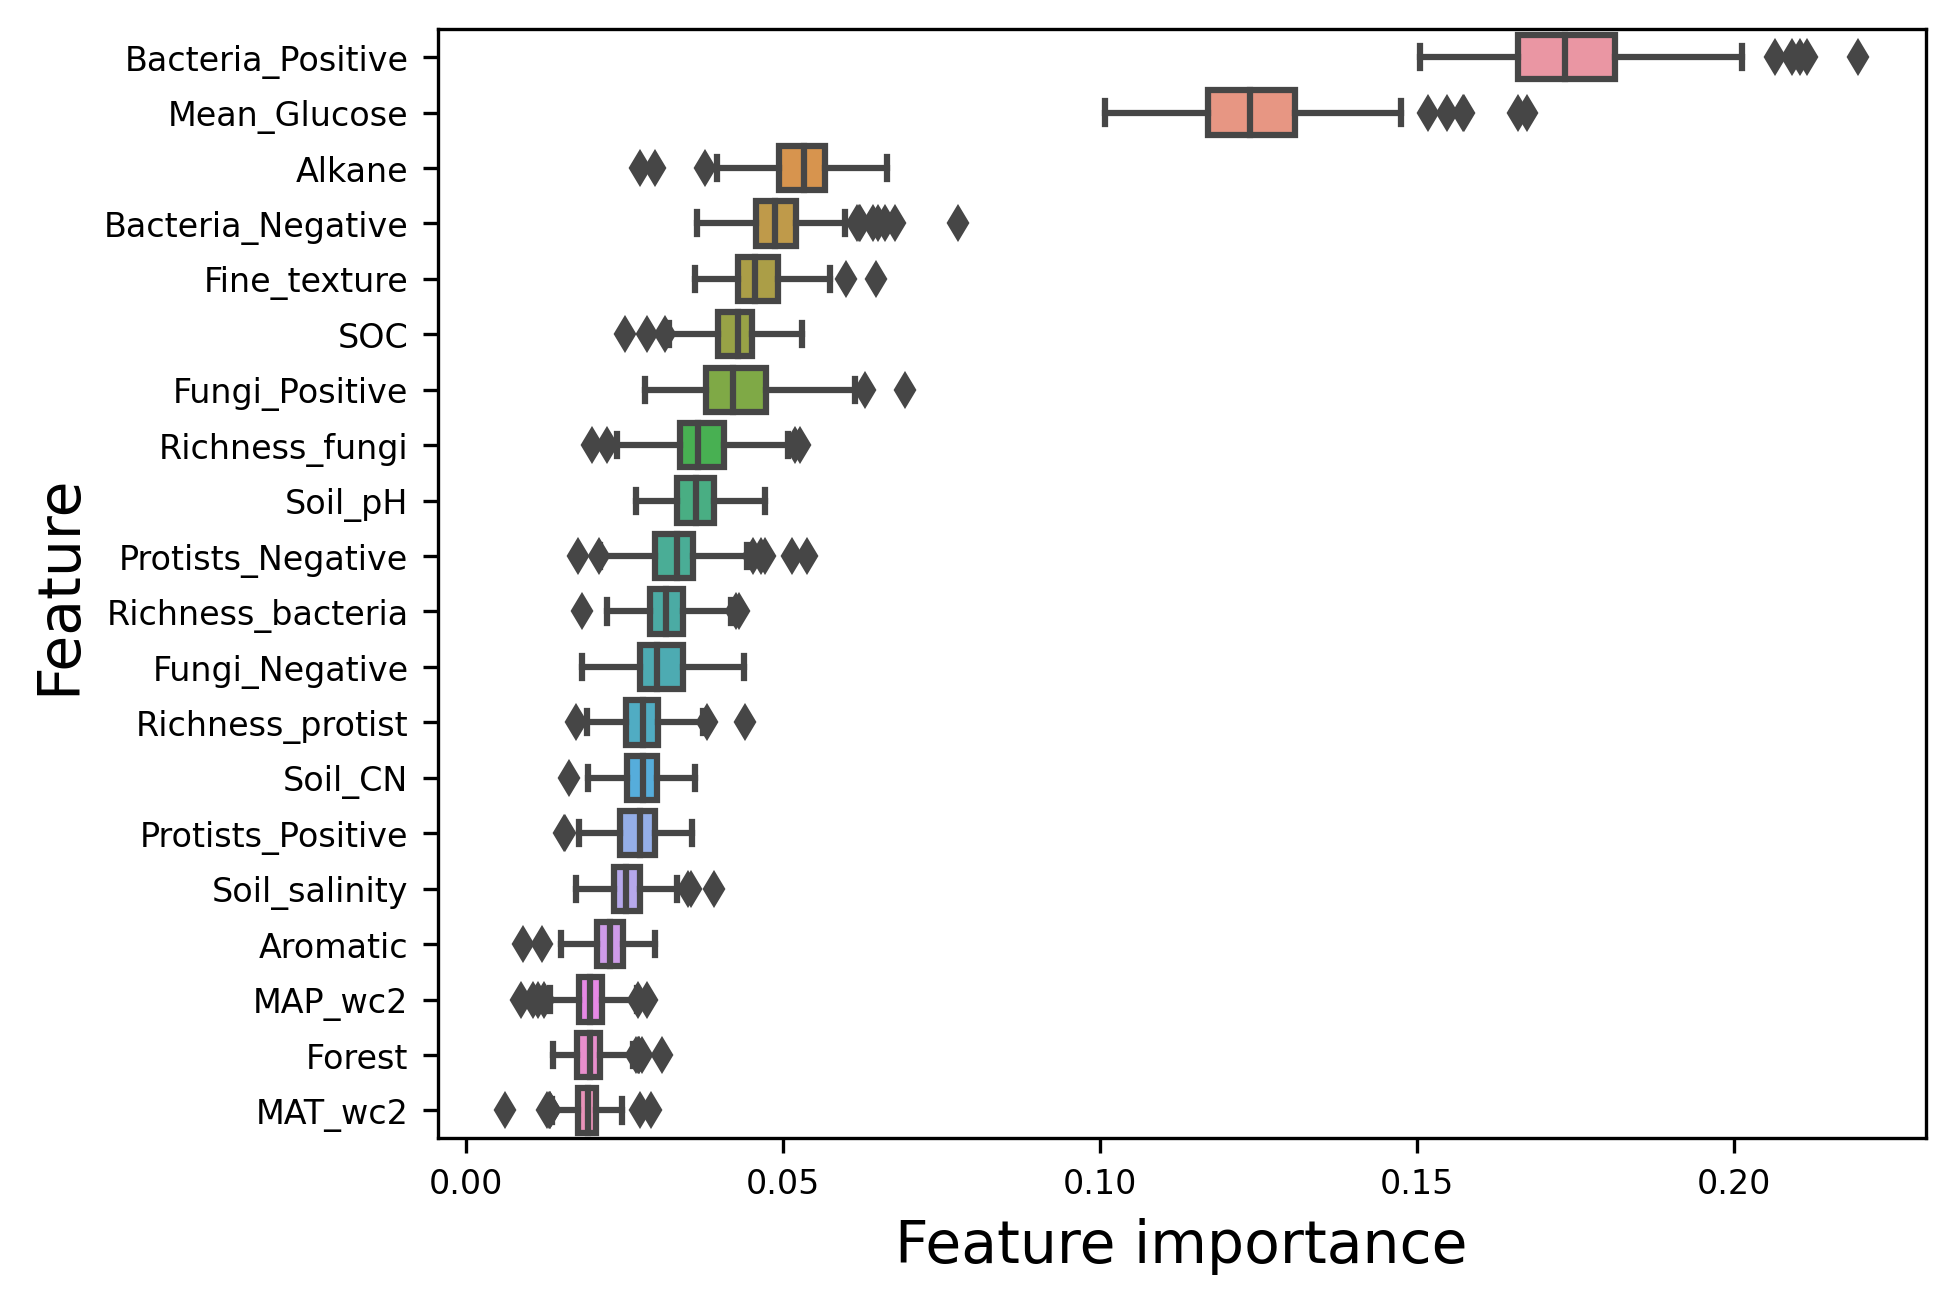

In [81]:
plt.figure(dpi=300)
sns.boxplot(y="feature name", x="coef. of importance", data=df_importance_xgb,order=grouped_xgb.index[:20])


plt.xticks(fontsize=8)
plt.yticks(fontsize=8)
plt.xlabel('Feature importance',fontsize=14)
plt.ylabel('Feature',fontsize=14)

In [83]:
# Establish lists to keep average Shap values, their Stds, and their min and max
average_shap_values, stds, ranges = [],[],[]

for i in X.index:
    df_per_obs = pd.DataFrame.from_dict(shap_values_per_cv[i]) # Get all SHAP values for sample number i
    # Get relevant statistics for every sample 
    average_shap_values.append(df_per_obs.mean(axis=1).values) 
    stds.append(df_per_obs.std(axis=1).values)
    ranges.append(df_per_obs.max(axis=1).values-df_per_obs.min(axis=1).values)

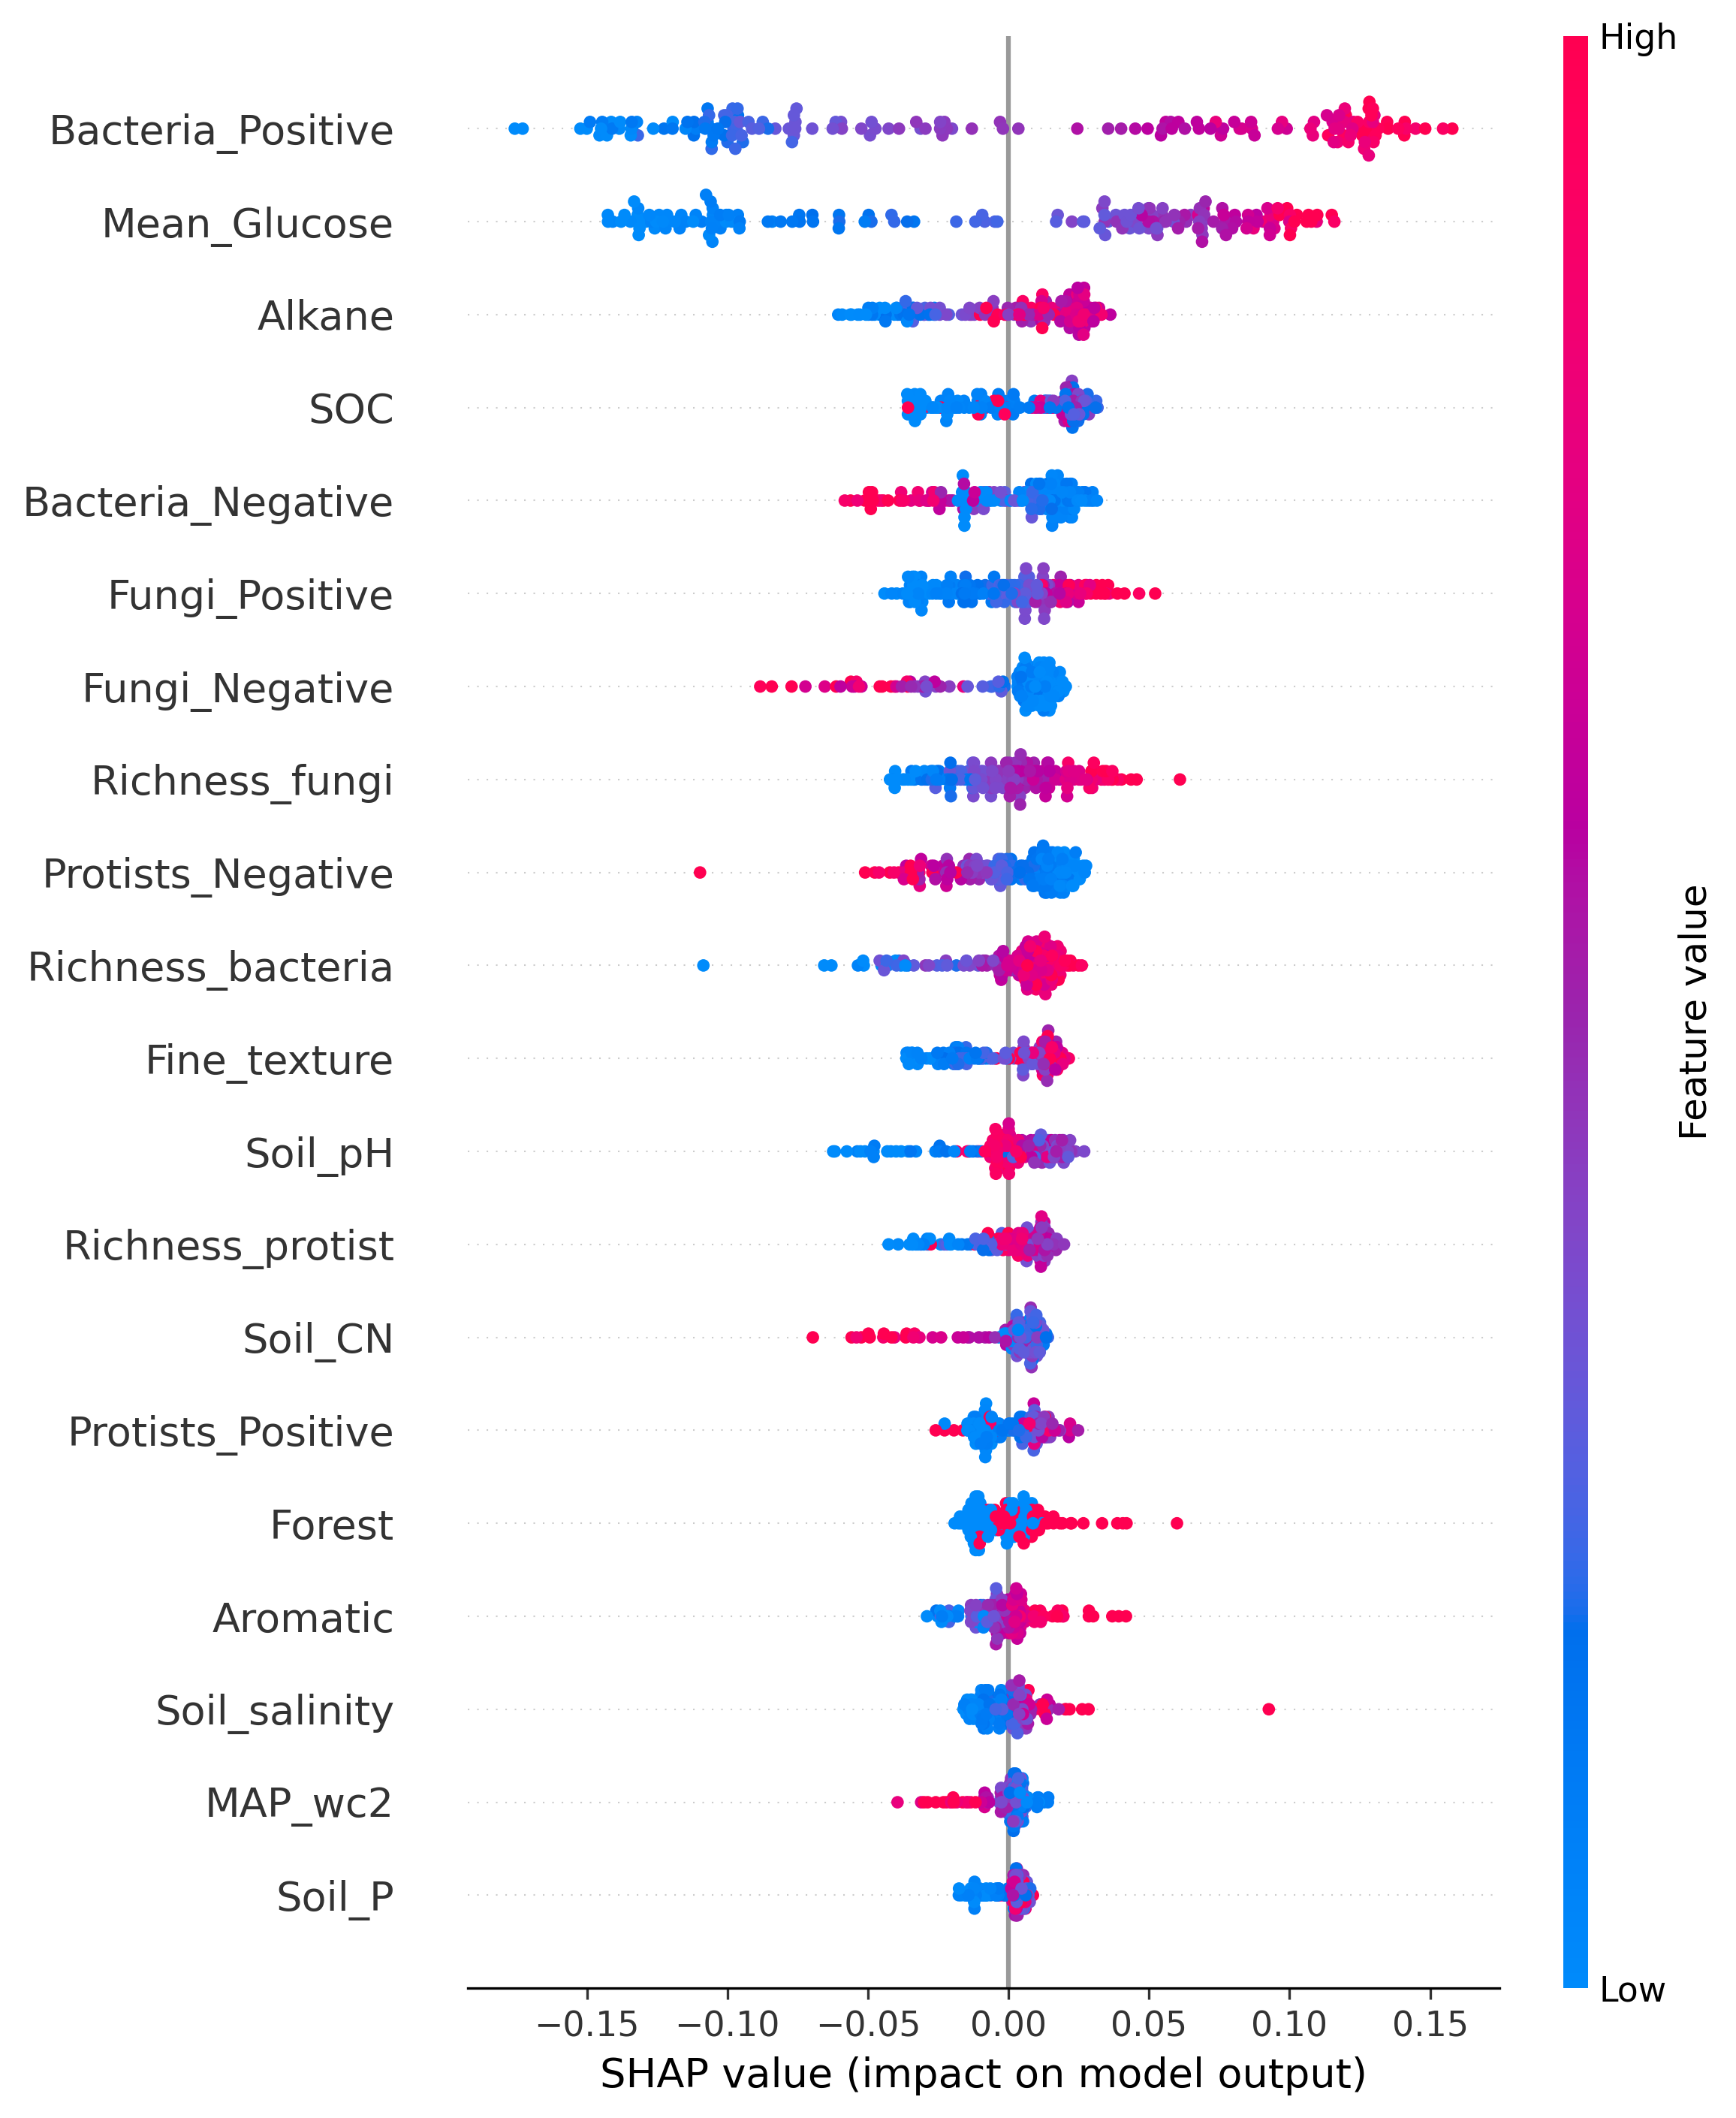

In [85]:
plt.figure(dpi=300)
shap.summary_plot(np.array(average_shap_values), X,max_display=20)

<Figure size 1920x1440 with 0 Axes>

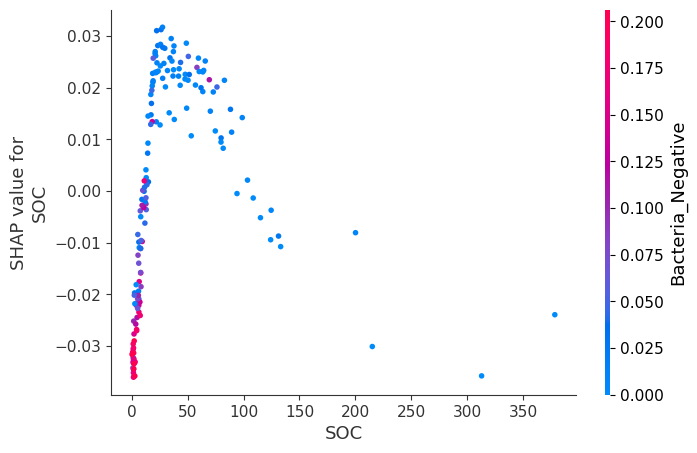

In [22]:
plt.figure(dpi=300)
shap.dependence_plot("rank(3)", np.array(average_shap_values), X)

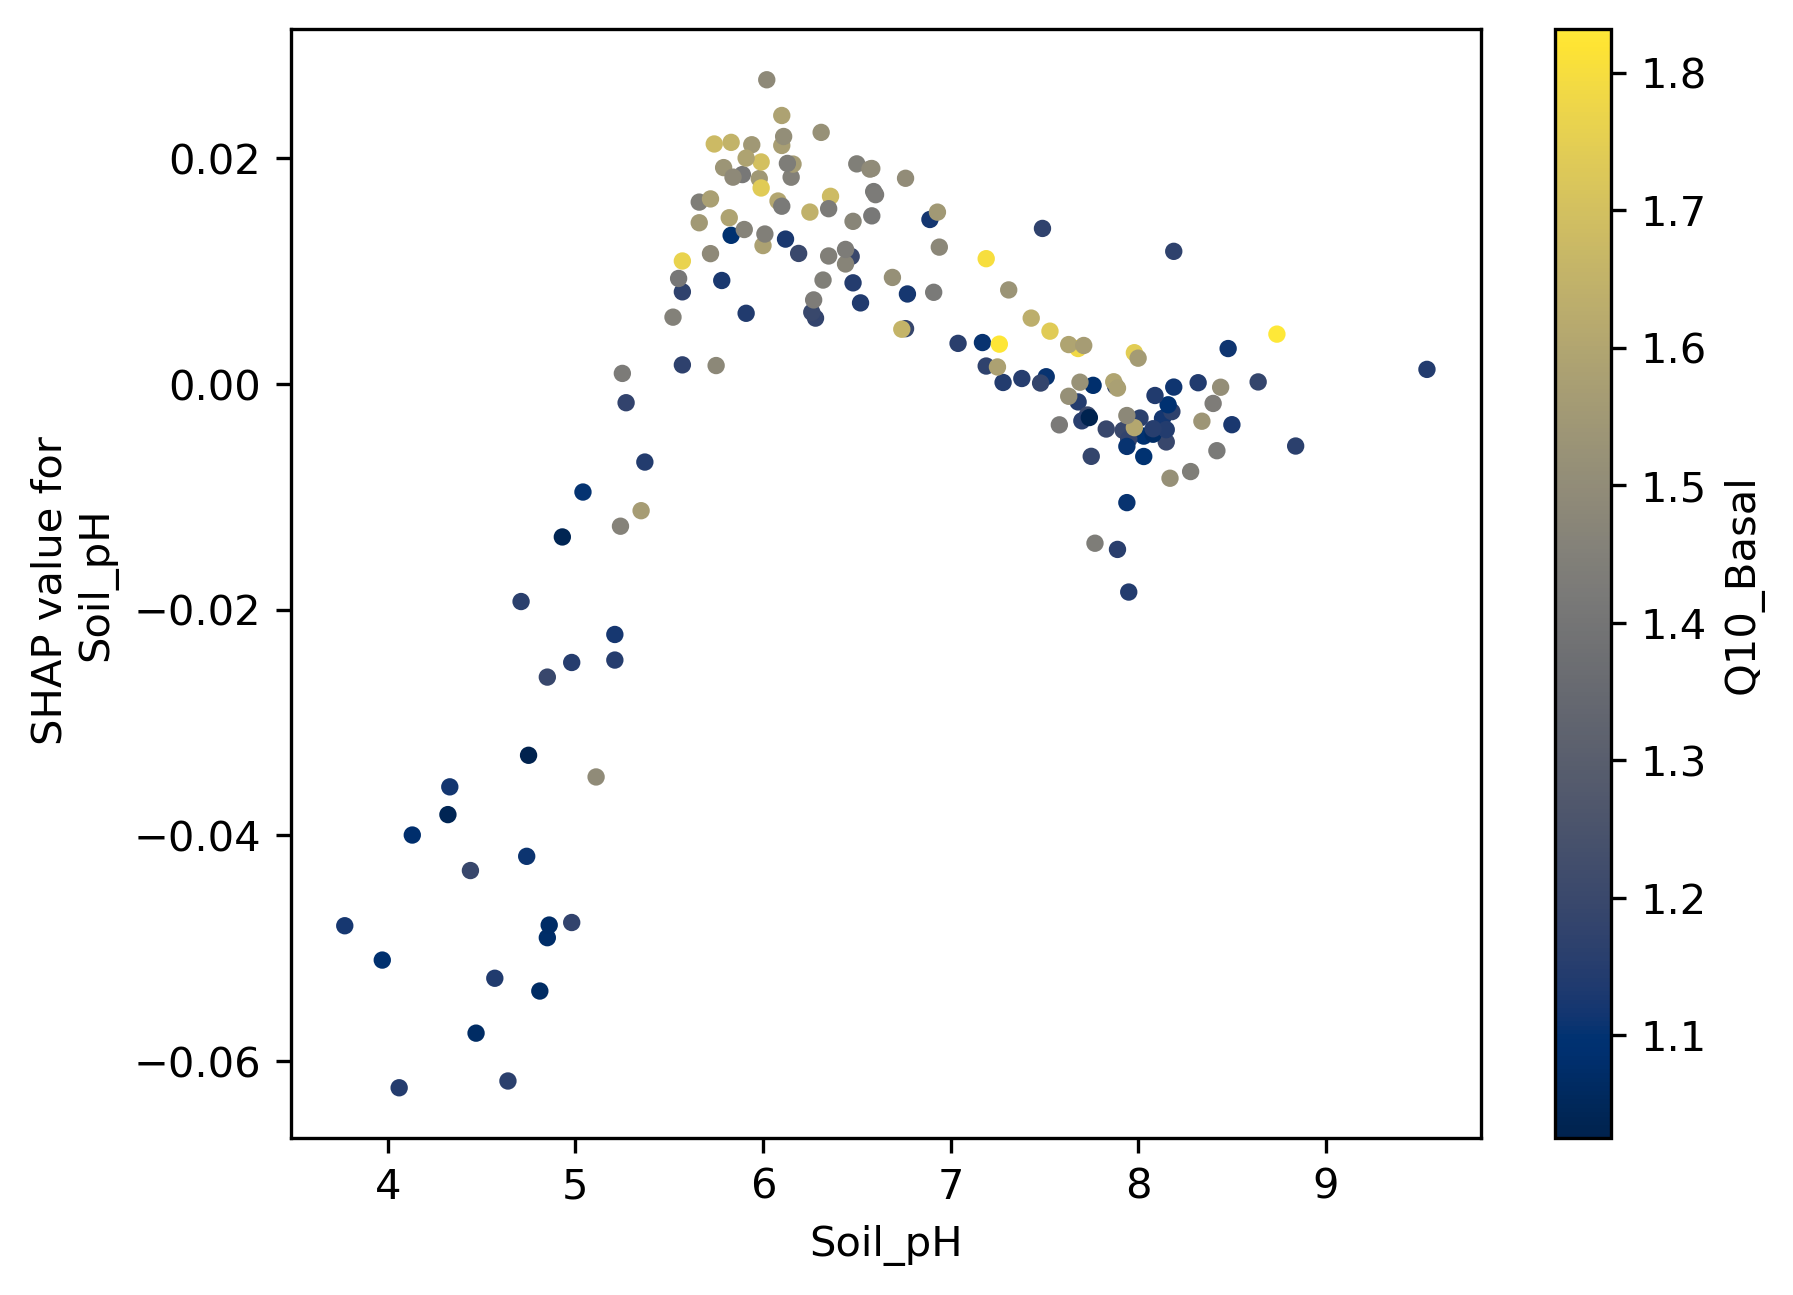

In [95]:
index=X.columns.get_loc("Soil_pH")
fig, ax =plt.subplots(nrows=1, ncols=1, dpi=300) 
p=ax.scatter(X.iloc[:,index].values, np.array(average_shap_values)[:,index], c=df["Q10_Basal"], s=10,cmap='cividis') # s is a size of marker 
ax.set_ylabel('SHAP value for \n'+ X.columns[index])
ax.set_xlabel(X.columns[index])
fig.colorbar(p,ax=ax,orientation='vertical',label='Q10_Basal')
plt.show()

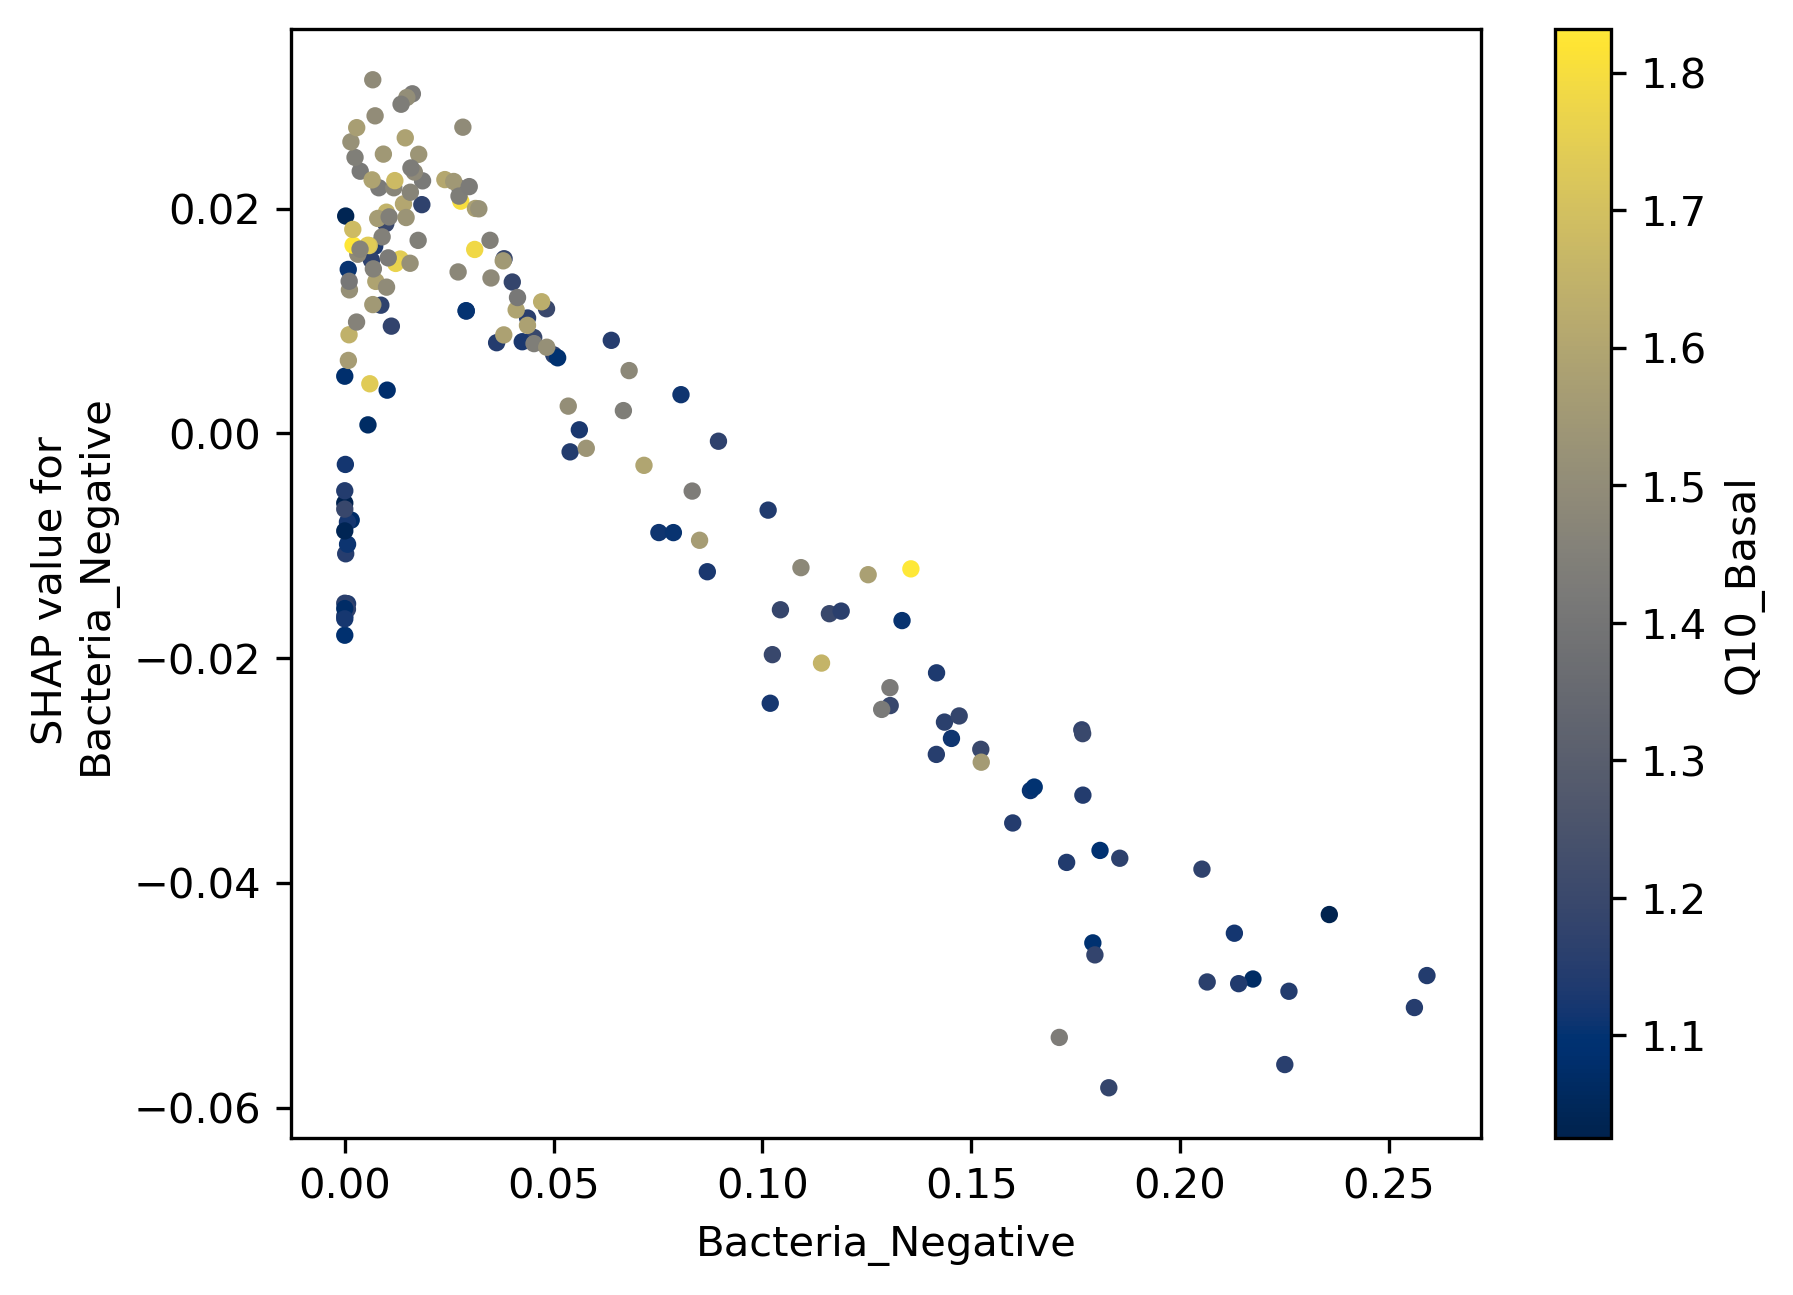

In [89]:

index=X.columns.get_loc("Bacteria_Negative")
fig, ax =plt.subplots(nrows=1, ncols=1, dpi=300) 
p=ax.scatter(X.iloc[:,index].values, np.array(average_shap_values)[:,index], c=df["Q10_Basal"], s=10,cmap='cividis') # s is a size of marker 
ax.set_ylabel('SHAP value for \n'+ X.columns[index])
ax.set_xlabel(X.columns[index])
fig.colorbar(p,ax=ax,orientation='vertical',label='Q10_Basal')
plt.show()

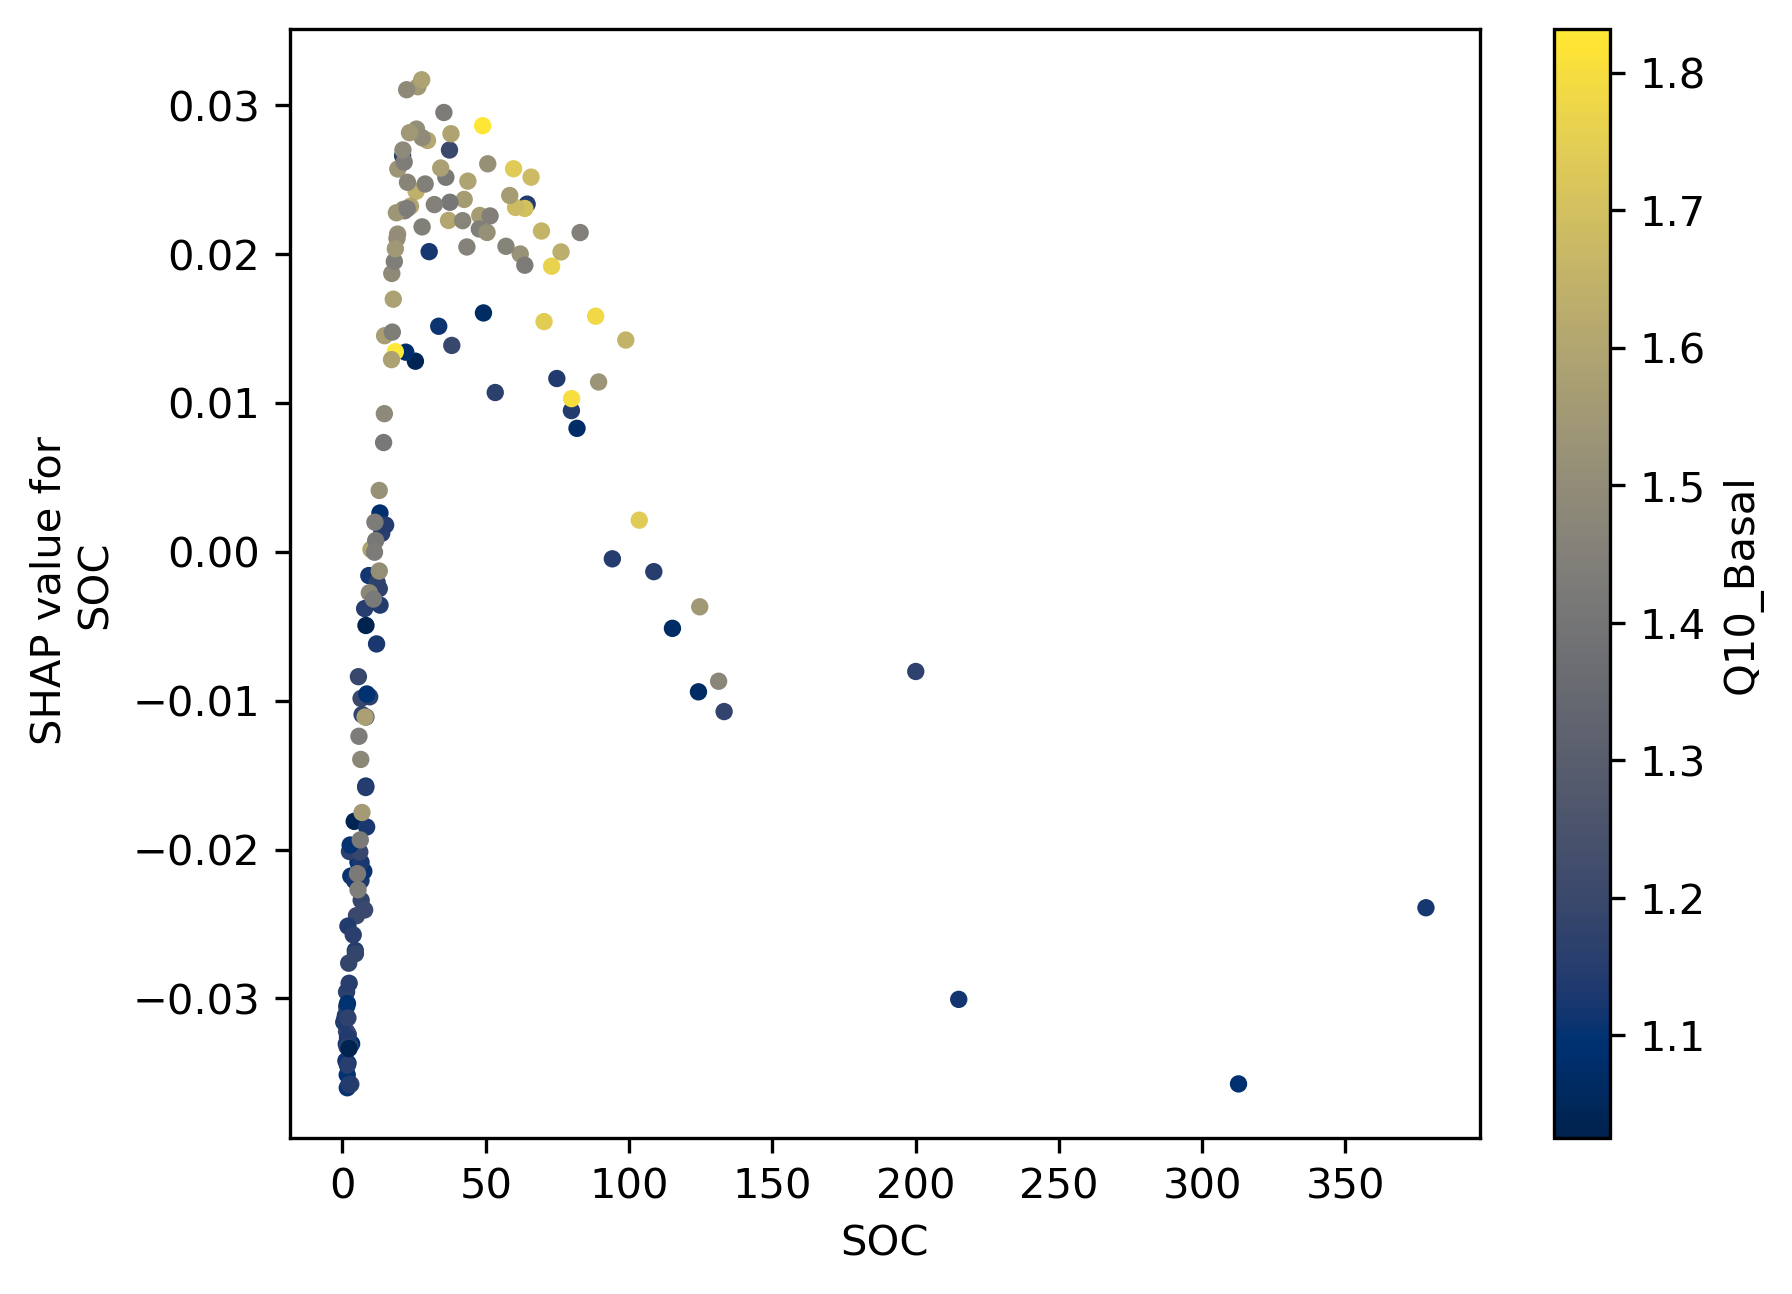

In [87]:

index=X.columns.get_loc("SOC")
fig, ax =plt.subplots(nrows=1, ncols=1, dpi=300) 
p=ax.scatter(X.iloc[:,index].values, np.array(average_shap_values)[:,index], c=df["Q10_Basal"], s=10,cmap='cividis') # s is a size of marker 
ax.set_ylabel('SHAP value for \n'+ X.columns[index])
ax.set_xlabel(X.columns[index])
fig.colorbar(p,ax=ax,orientation='vertical',label='Q10_Basal')
plt.show()

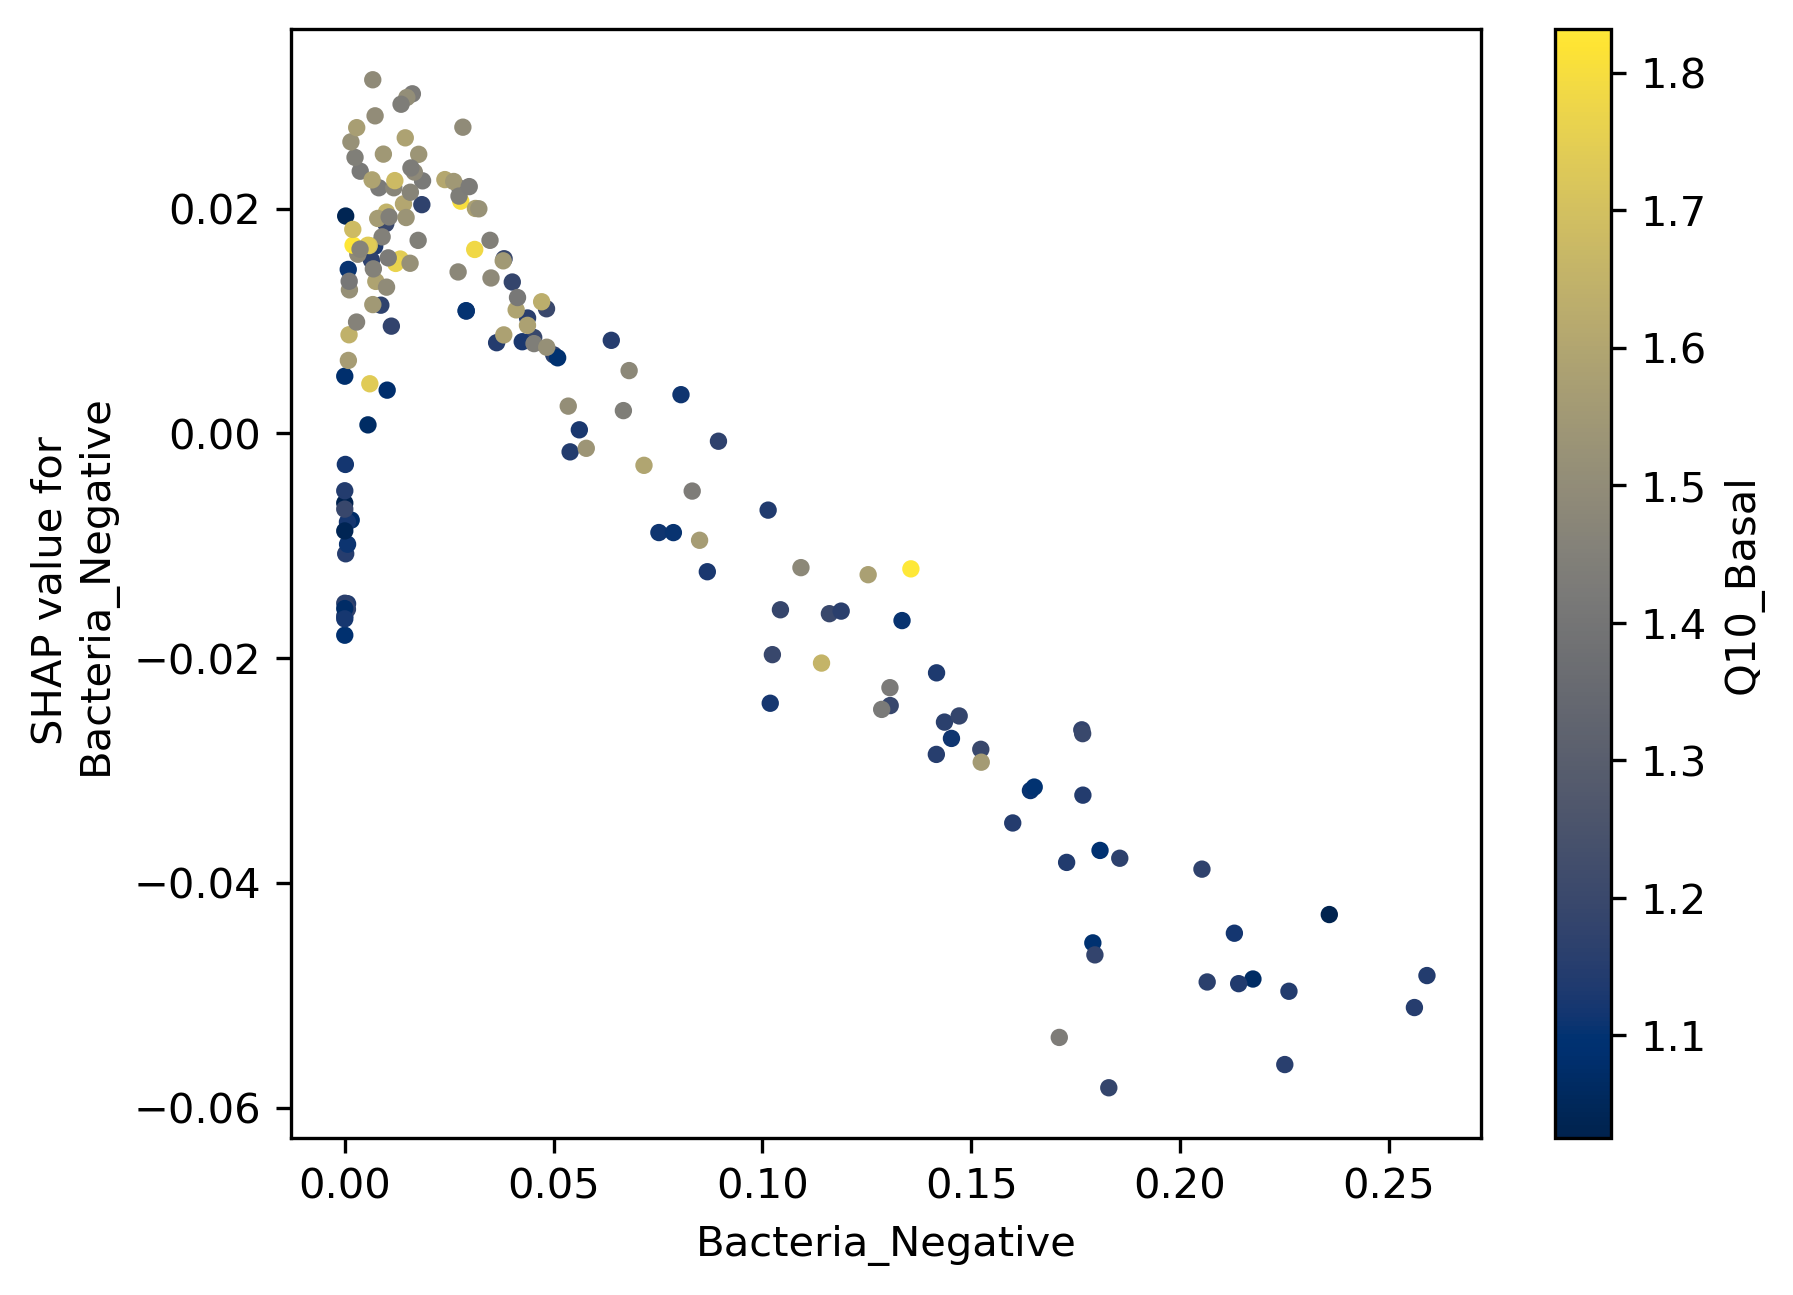

In [23]:

index=X.columns.get_loc("Bacteria_Negative")
fig, ax =plt.subplots(nrows=1, ncols=1, dpi=300) 
p=ax.scatter(X.iloc[:,index].values, np.array(average_shap_values)[:,index], c=df["Q10_Basal"], s=10,cmap='cividis') # s is a size of marker 
ax.set_ylabel('SHAP value for \n'+ X.columns[index])
ax.set_xlabel(X.columns[index])
fig.colorbar(p,ax=ax,orientation='vertical',label='Q10_Basal')
plt.show()

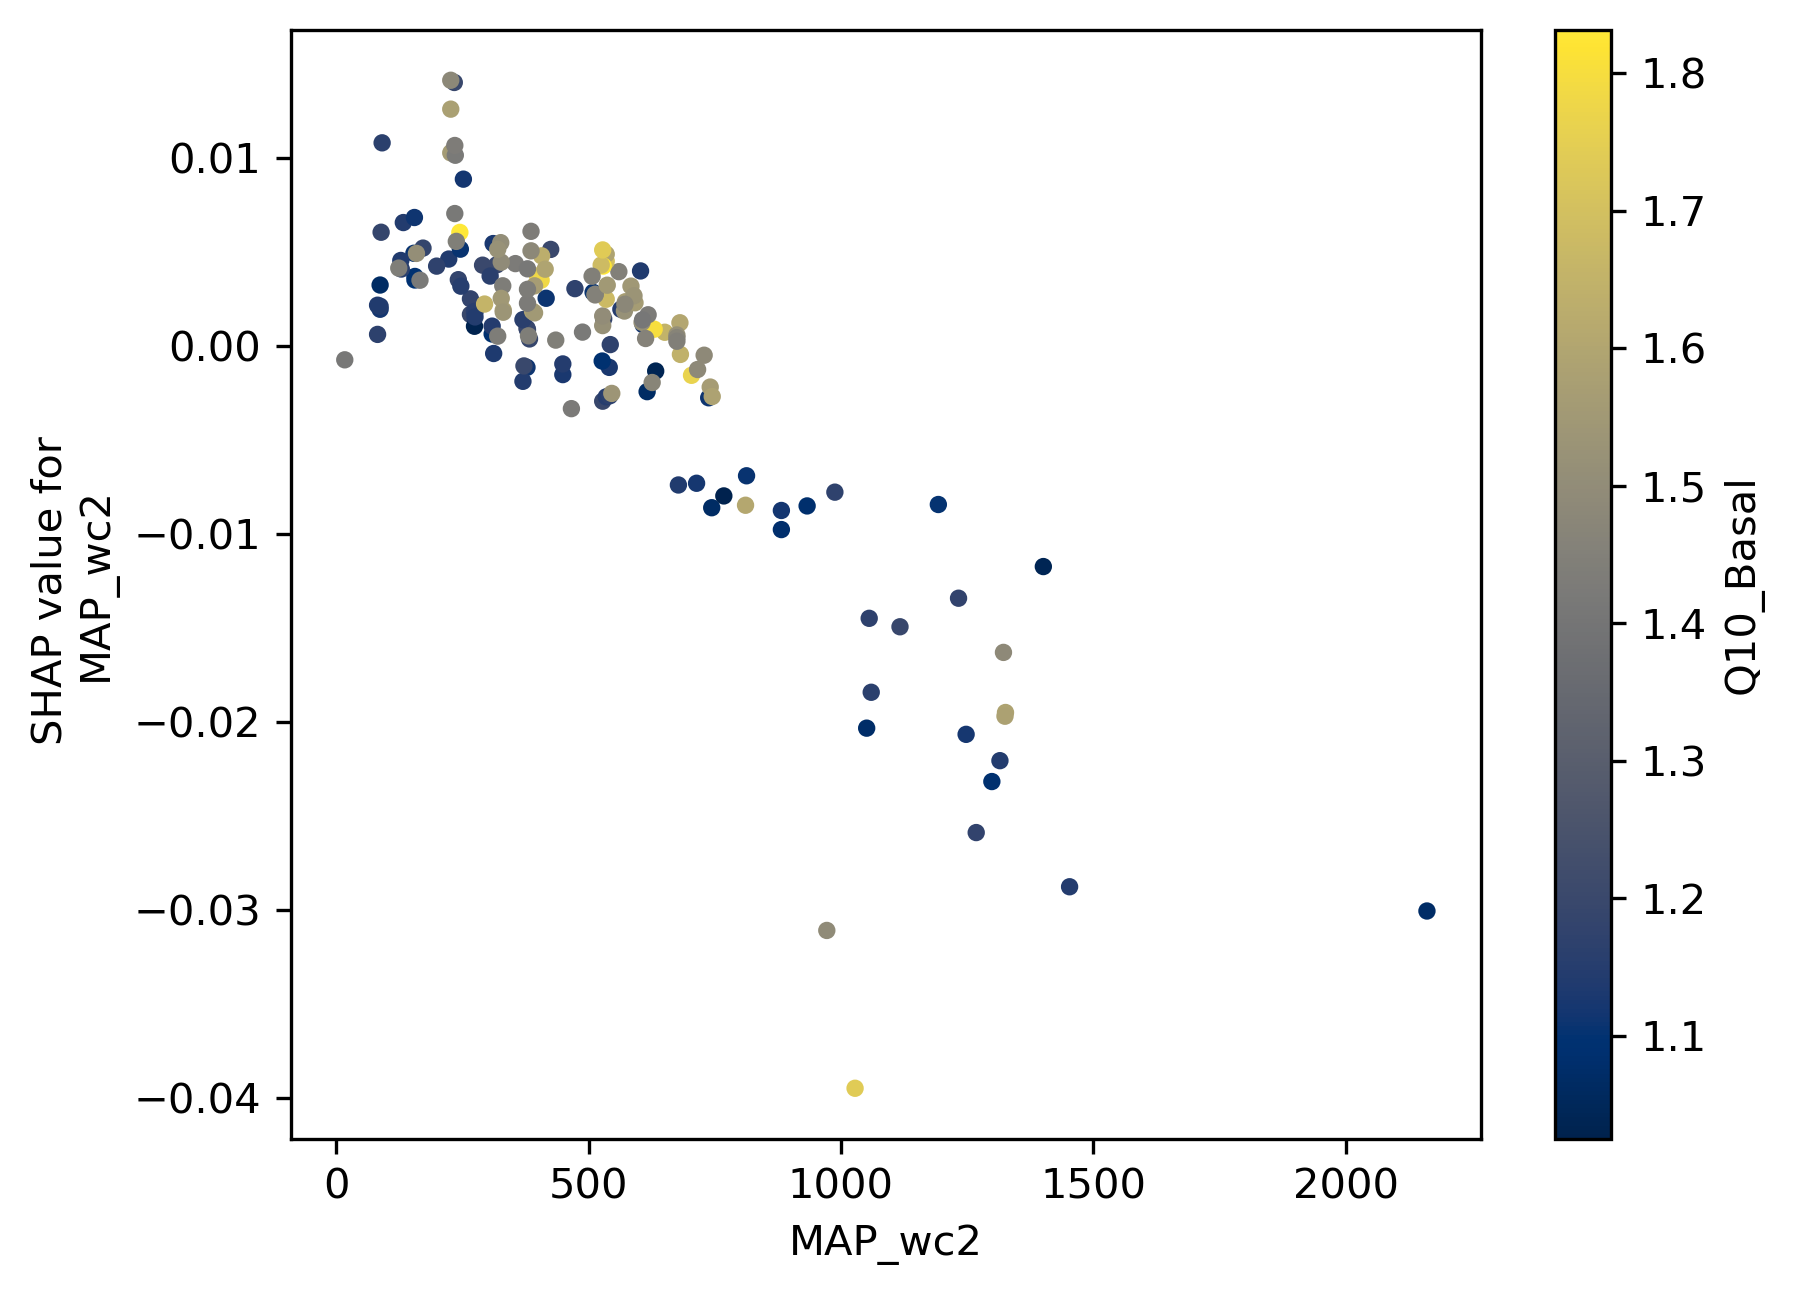

In [24]:

index=X.columns.get_loc("MAP_wc2")
fig, ax =plt.subplots(nrows=1, ncols=1, dpi=300) 
p=ax.scatter(X.iloc[:,index].values, np.array(average_shap_values)[:,index], c=df["Q10_Basal"], s=10,cmap='cividis') # s is a size of marker 
ax.set_ylabel('SHAP value for \n'+ X.columns[index])
ax.set_xlabel(X.columns[index])
fig.colorbar(p,ax=ax,orientation='vertical',label='Q10_Basal')
plt.show()

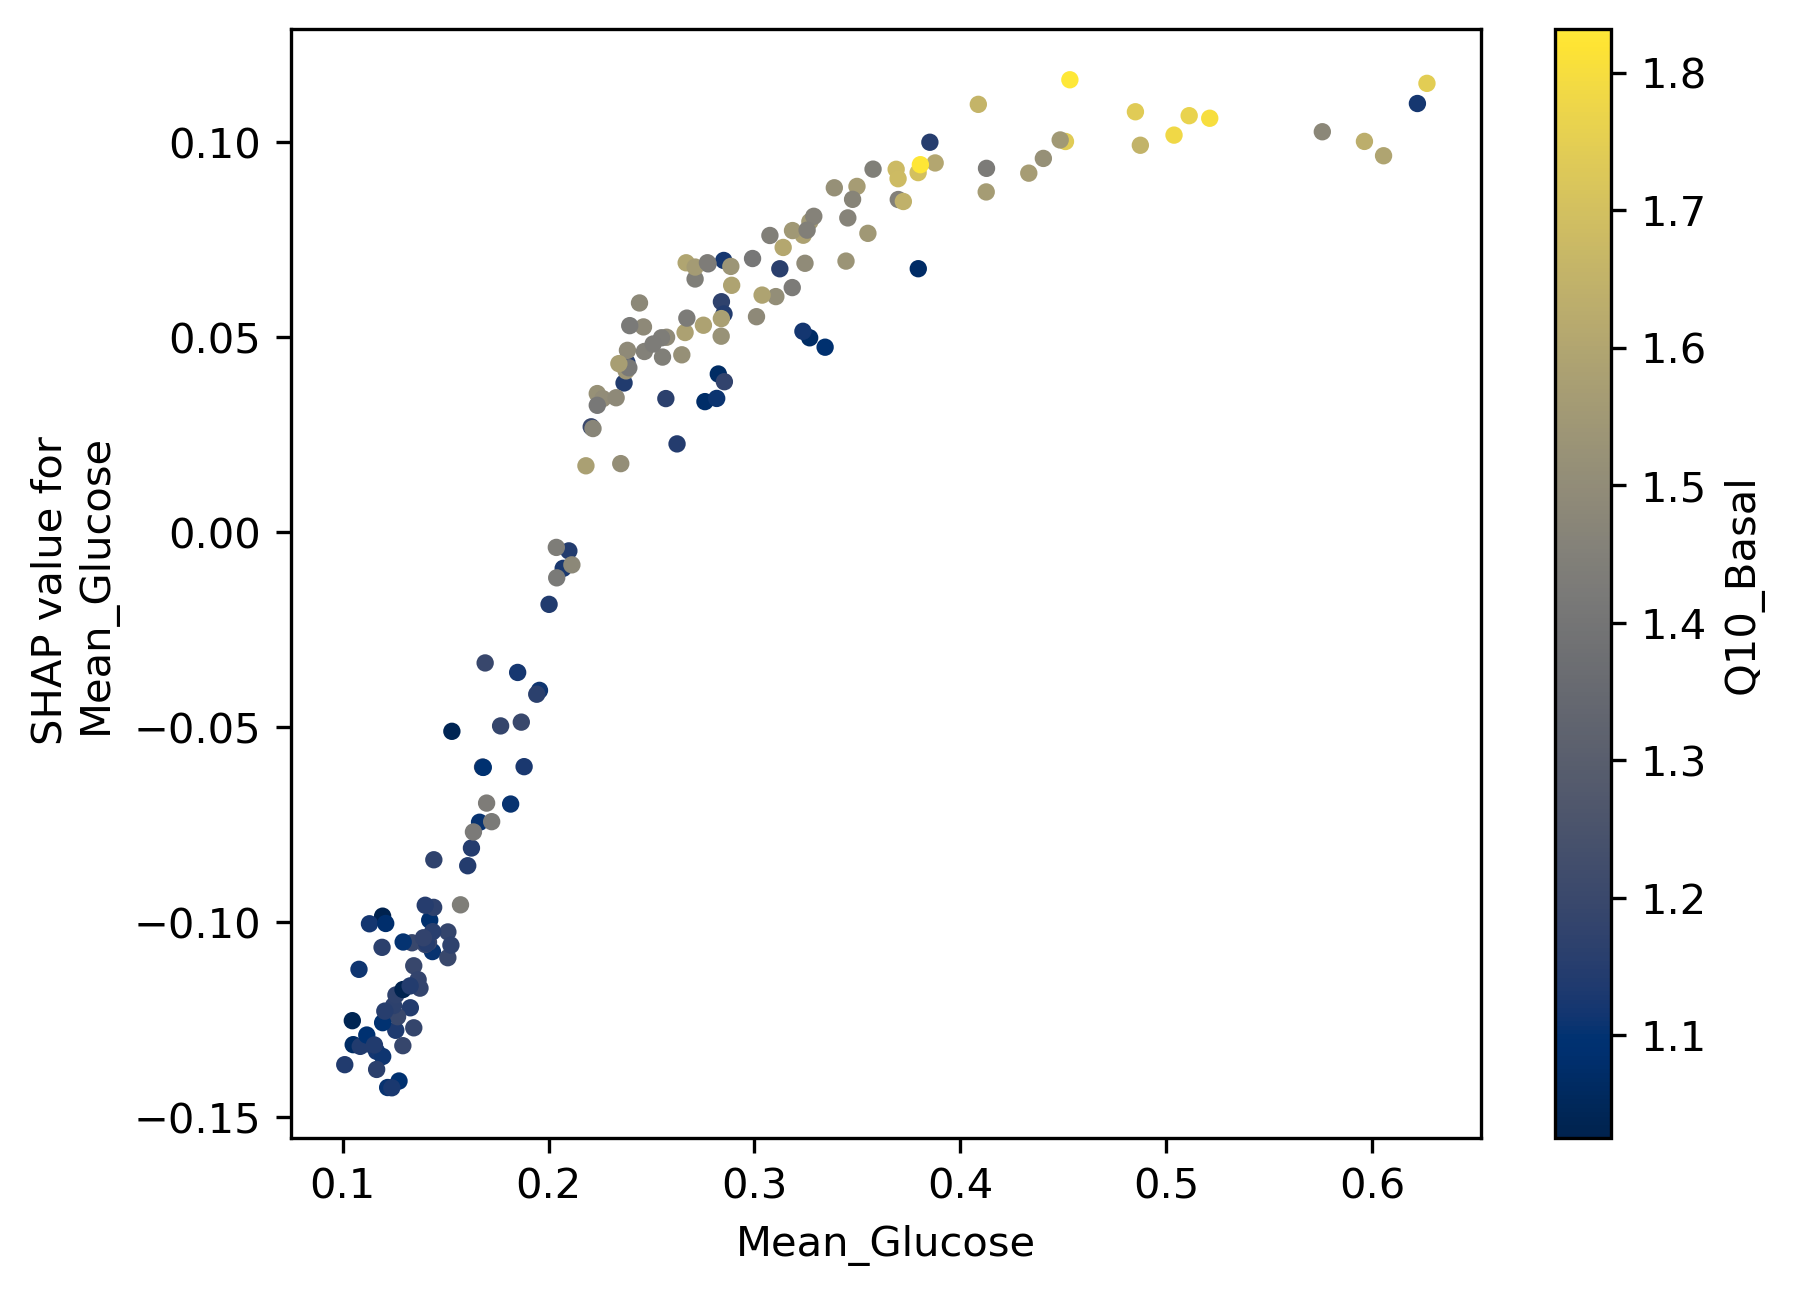

In [25]:

index=X.columns.get_loc("Mean_Glucose")
fig, ax =plt.subplots(nrows=1, ncols=1, dpi=300) 
p=ax.scatter(X.iloc[:,index].values, np.array(average_shap_values)[:,index], c=df["Q10_Basal"], s=10,cmap='cividis') # s is a size of marker 
ax.set_ylabel('SHAP value for \n'+ X.columns[index])
ax.set_xlabel(X.columns[index])
fig.colorbar(p,ax=ax,orientation='vertical',label='Q10_Basal')
plt.show()


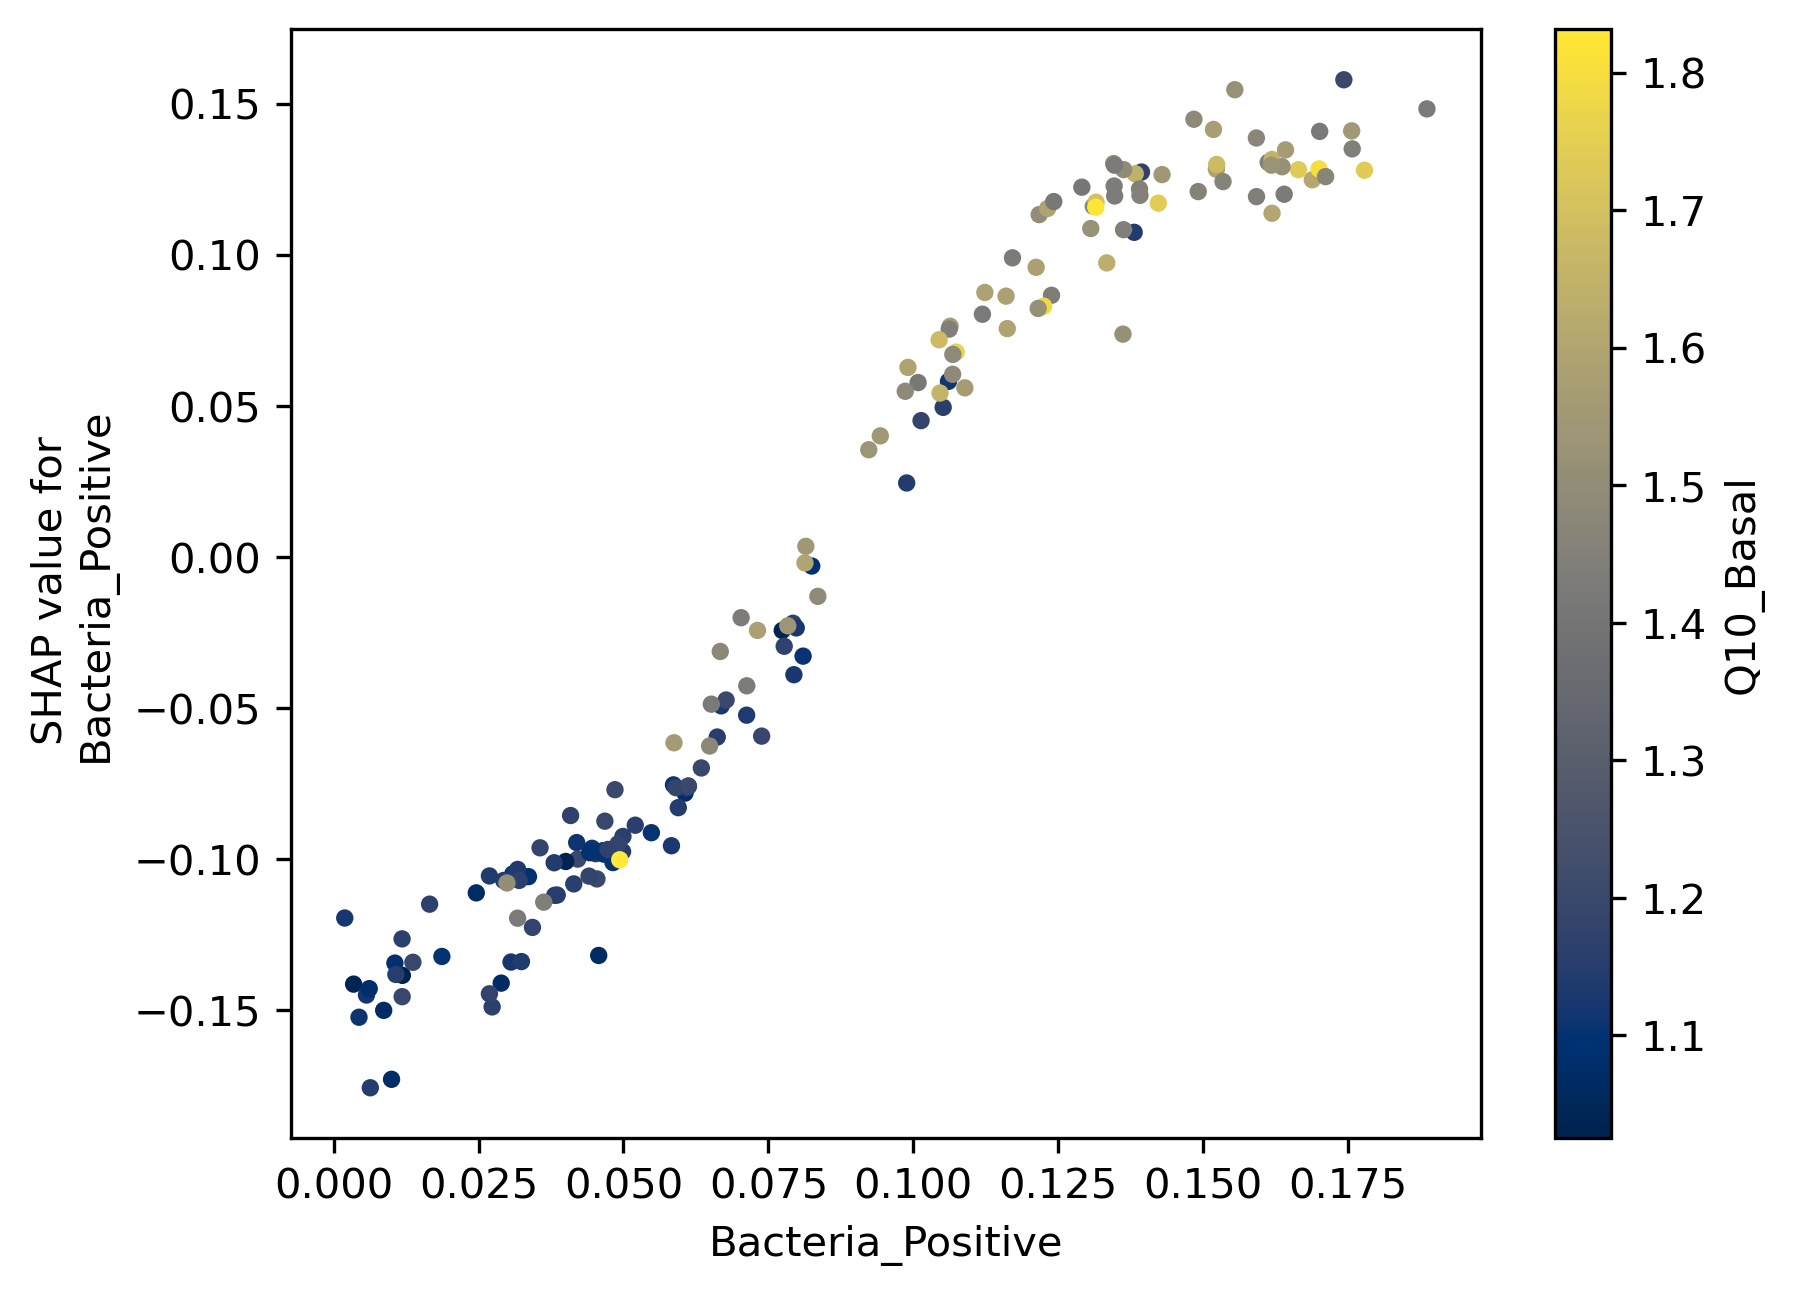

In [26]:
index=X.columns.get_loc("Bacteria_Positive")
fig, ax =plt.subplots(nrows=1, ncols=1, dpi=300) 
p=ax.scatter(X.iloc[:,index].values, np.array(average_shap_values)[:,index], c=df["Q10_Basal"], s=10,cmap='cividis') # s is a size of marker 
ax.set_ylabel('SHAP value for \n'+ X.columns[index])
ax.set_xlabel(X.columns[index])
fig.colorbar(p,ax=ax,orientation='vertical',label='Q10_Basal')
plt.show()

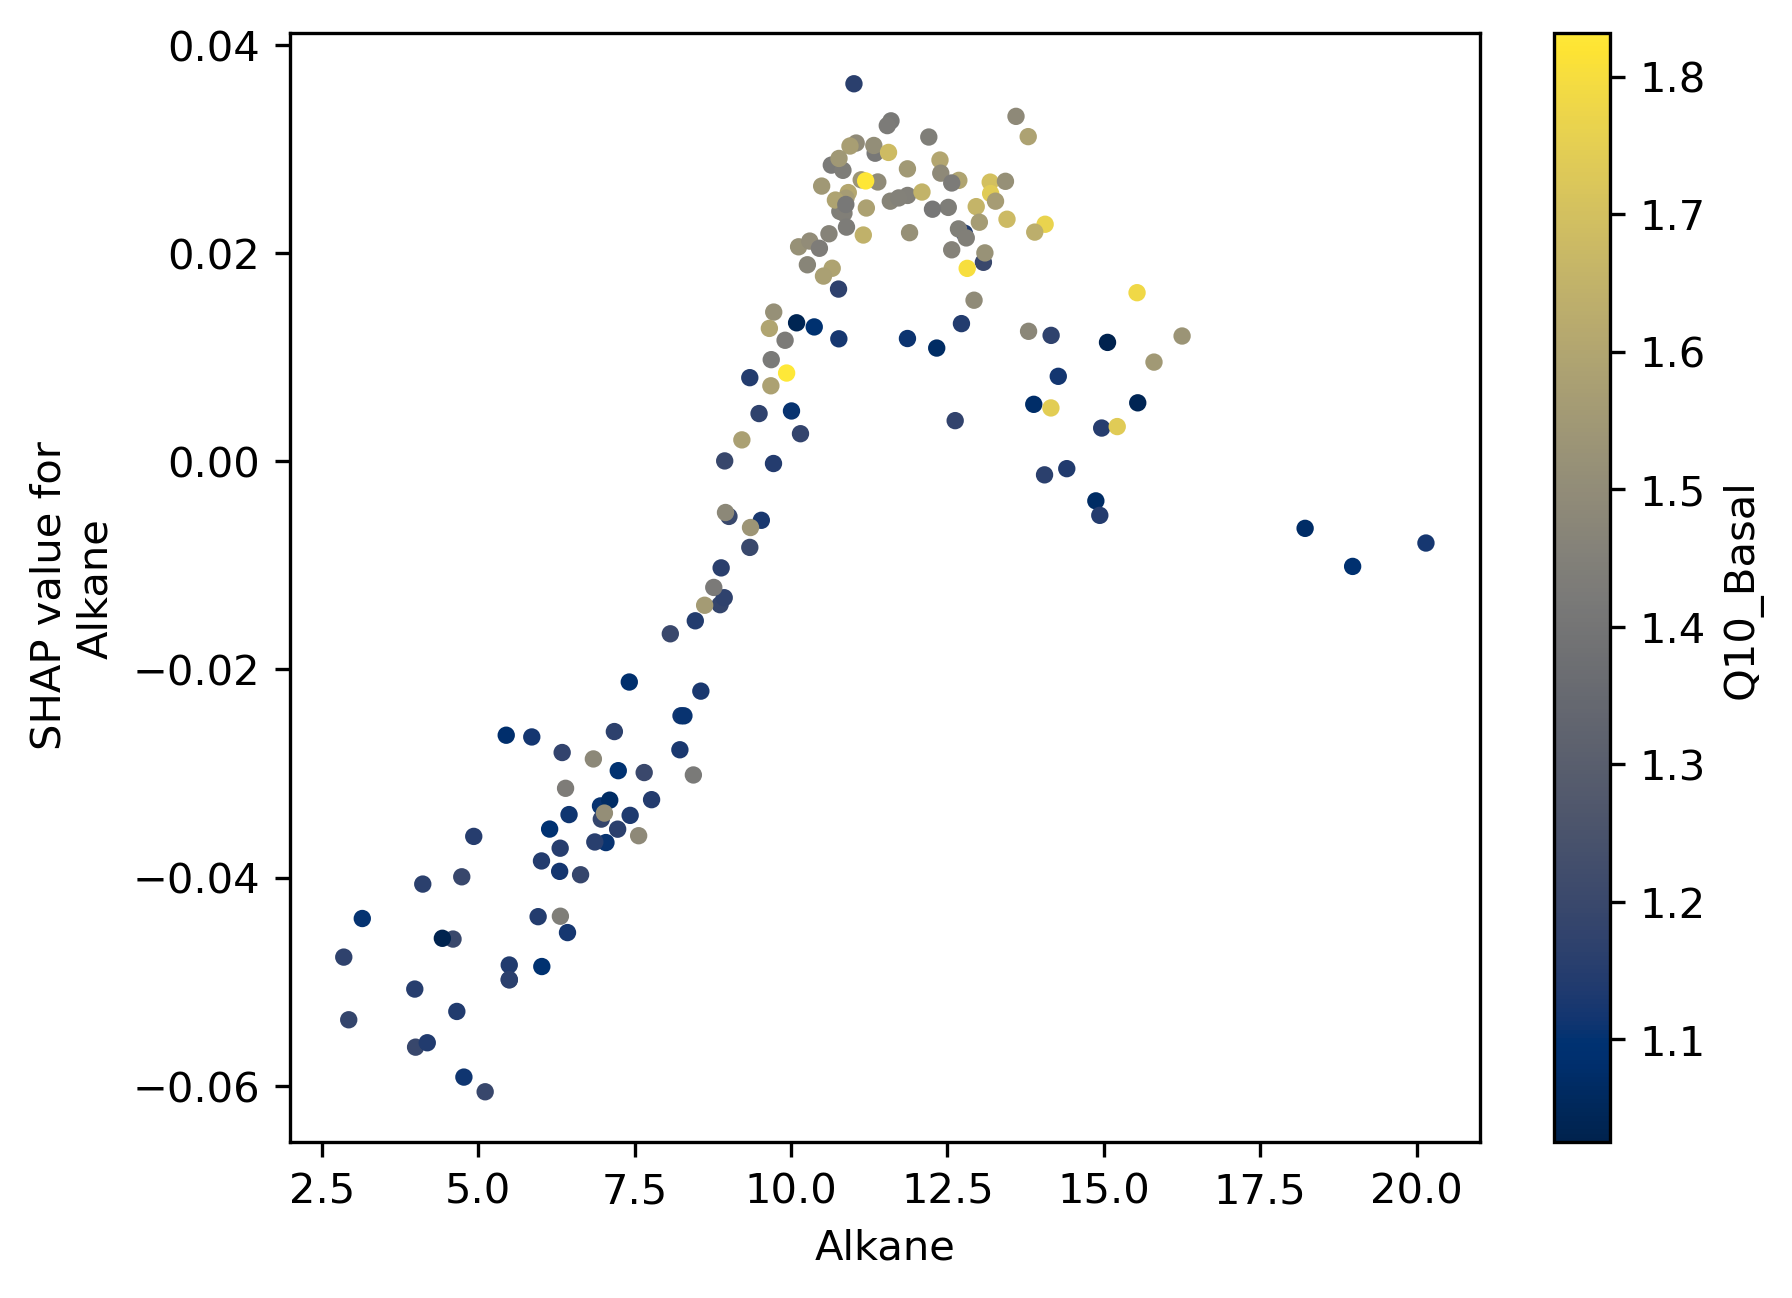

In [27]:
index=X.columns.get_loc("Alkane")
fig, ax =plt.subplots(nrows=1, ncols=1, dpi=300) 
p=ax.scatter(X.iloc[:,index].values, np.array(average_shap_values)[:,index], c=df["Q10_Basal"], s=10,cmap='cividis') # s is a size of marker 
ax.set_ylabel('SHAP value for \n'+ X.columns[index])
ax.set_xlabel(X.columns[index])
fig.colorbar(p,ax=ax,orientation='vertical',label='Q10_Basal')
plt.show()

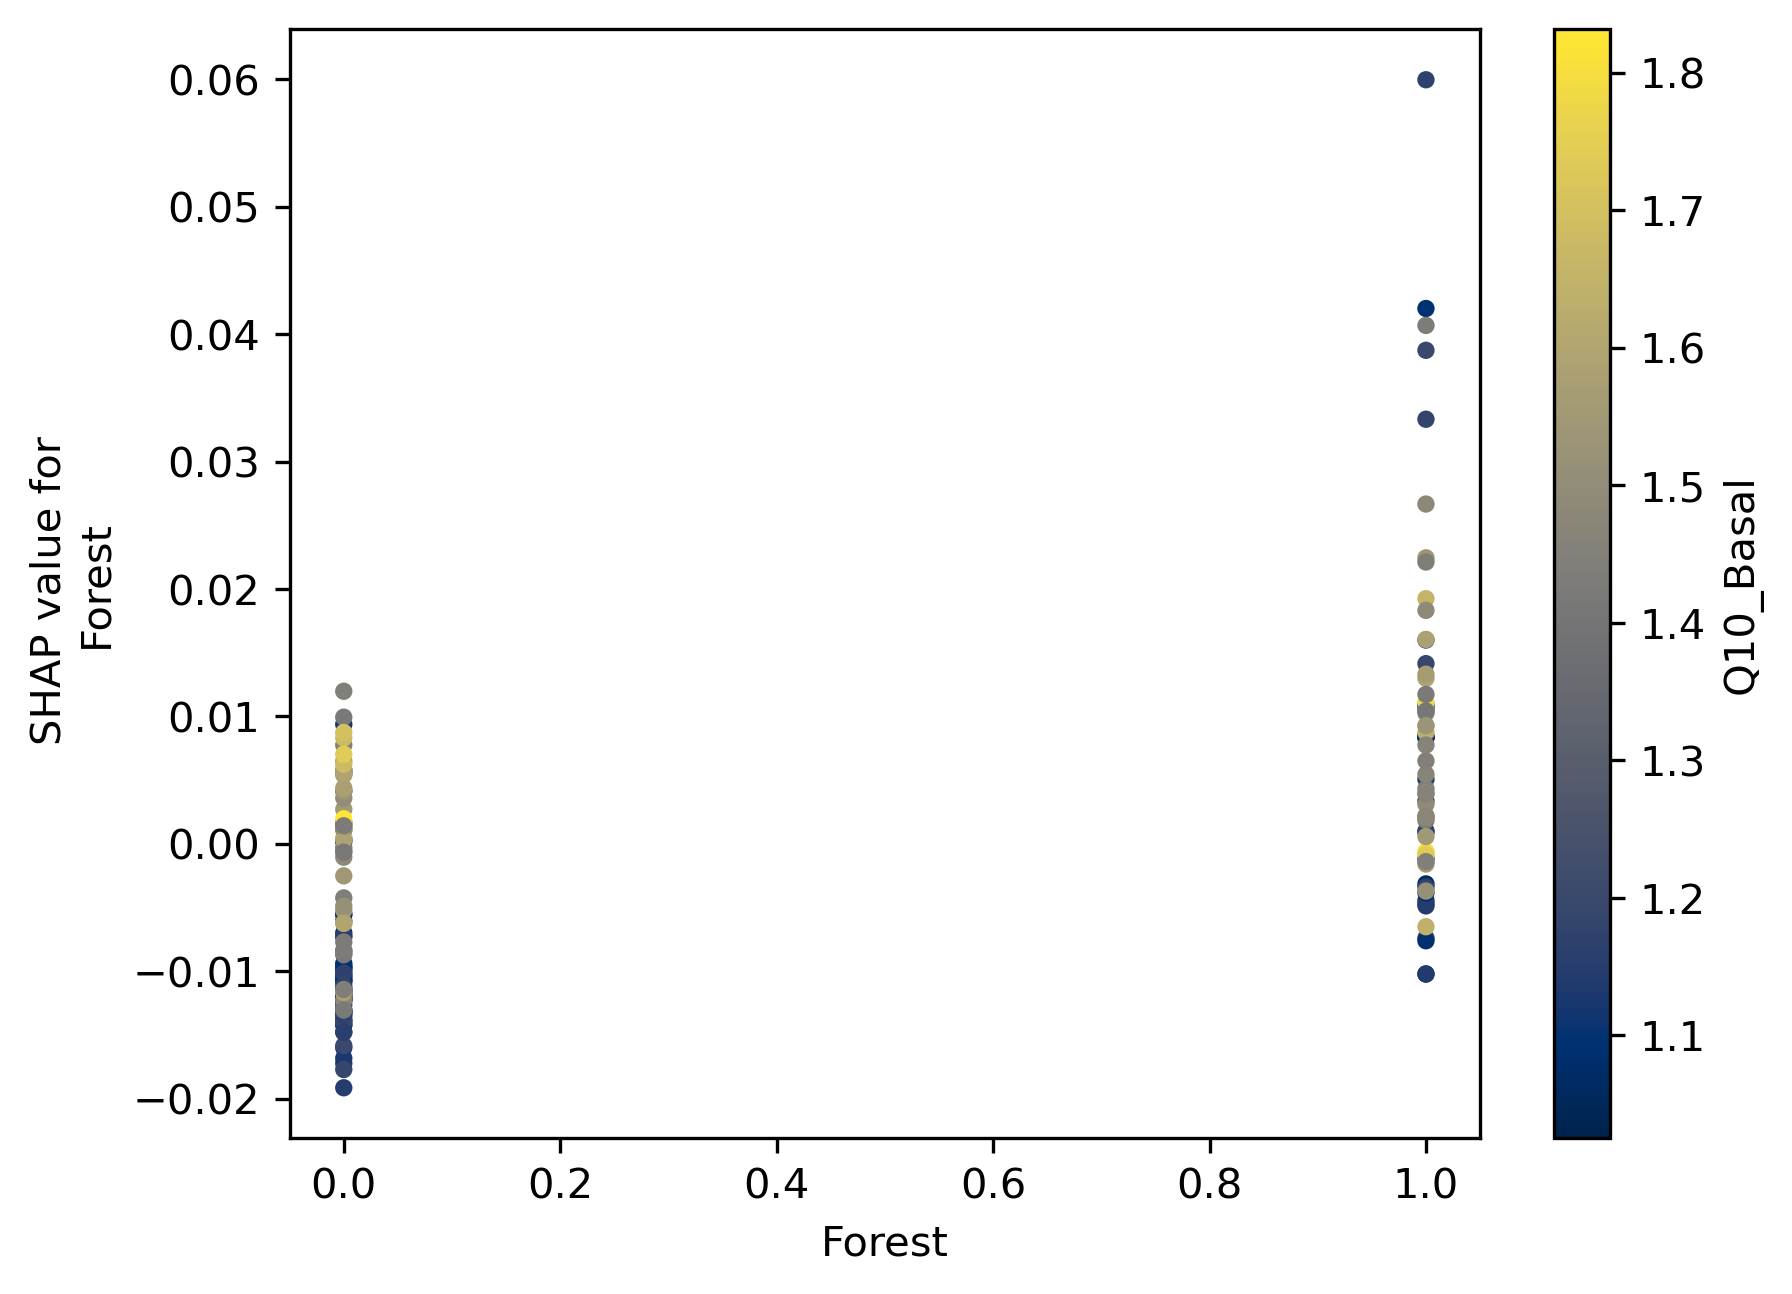

In [28]:
index=X.columns.get_loc("Forest")
fig, ax =plt.subplots(nrows=1, ncols=1, dpi=300) 
p=ax.scatter(X.iloc[:,index].values, np.array(average_shap_values)[:,index], c=df["Q10_Basal"], s=10,cmap='cividis') # s is a size of marker 
ax.set_ylabel('SHAP value for \n'+ X.columns[index])
ax.set_xlabel(X.columns[index])
fig.colorbar(p,ax=ax,orientation='vertical',label='Q10_Basal')
plt.show()

In [29]:
n_estim=list()
depth=list()
colsample=list()
for i in range(len(parameters)):
    n_estim.append(parameters[i]['n_estimators'])
#    colsample.append(parameters[i]['colsample_bytree'])
    if parameters[i]['max_depth']==None:
        depth.append('None')
    else:
        depth.append(str(parameters[i]['max_depth']))
        
parameters_dict=dict()
parameters_dict['n_estimators']=n_estim
parameters_dict['max_depth']=depth
#parameters_dict['colsample_bytree']=colsample

In [30]:
stability_param=pd.DataFrame.from_dict(parameters_dict)
stability_param

,n_estimators,max_depth
0,200,7
1,200,None
2,150,9
3,200,None
4,200,None
...,...,...
195,250,None
196,100,9
197,150,None
198,200,None


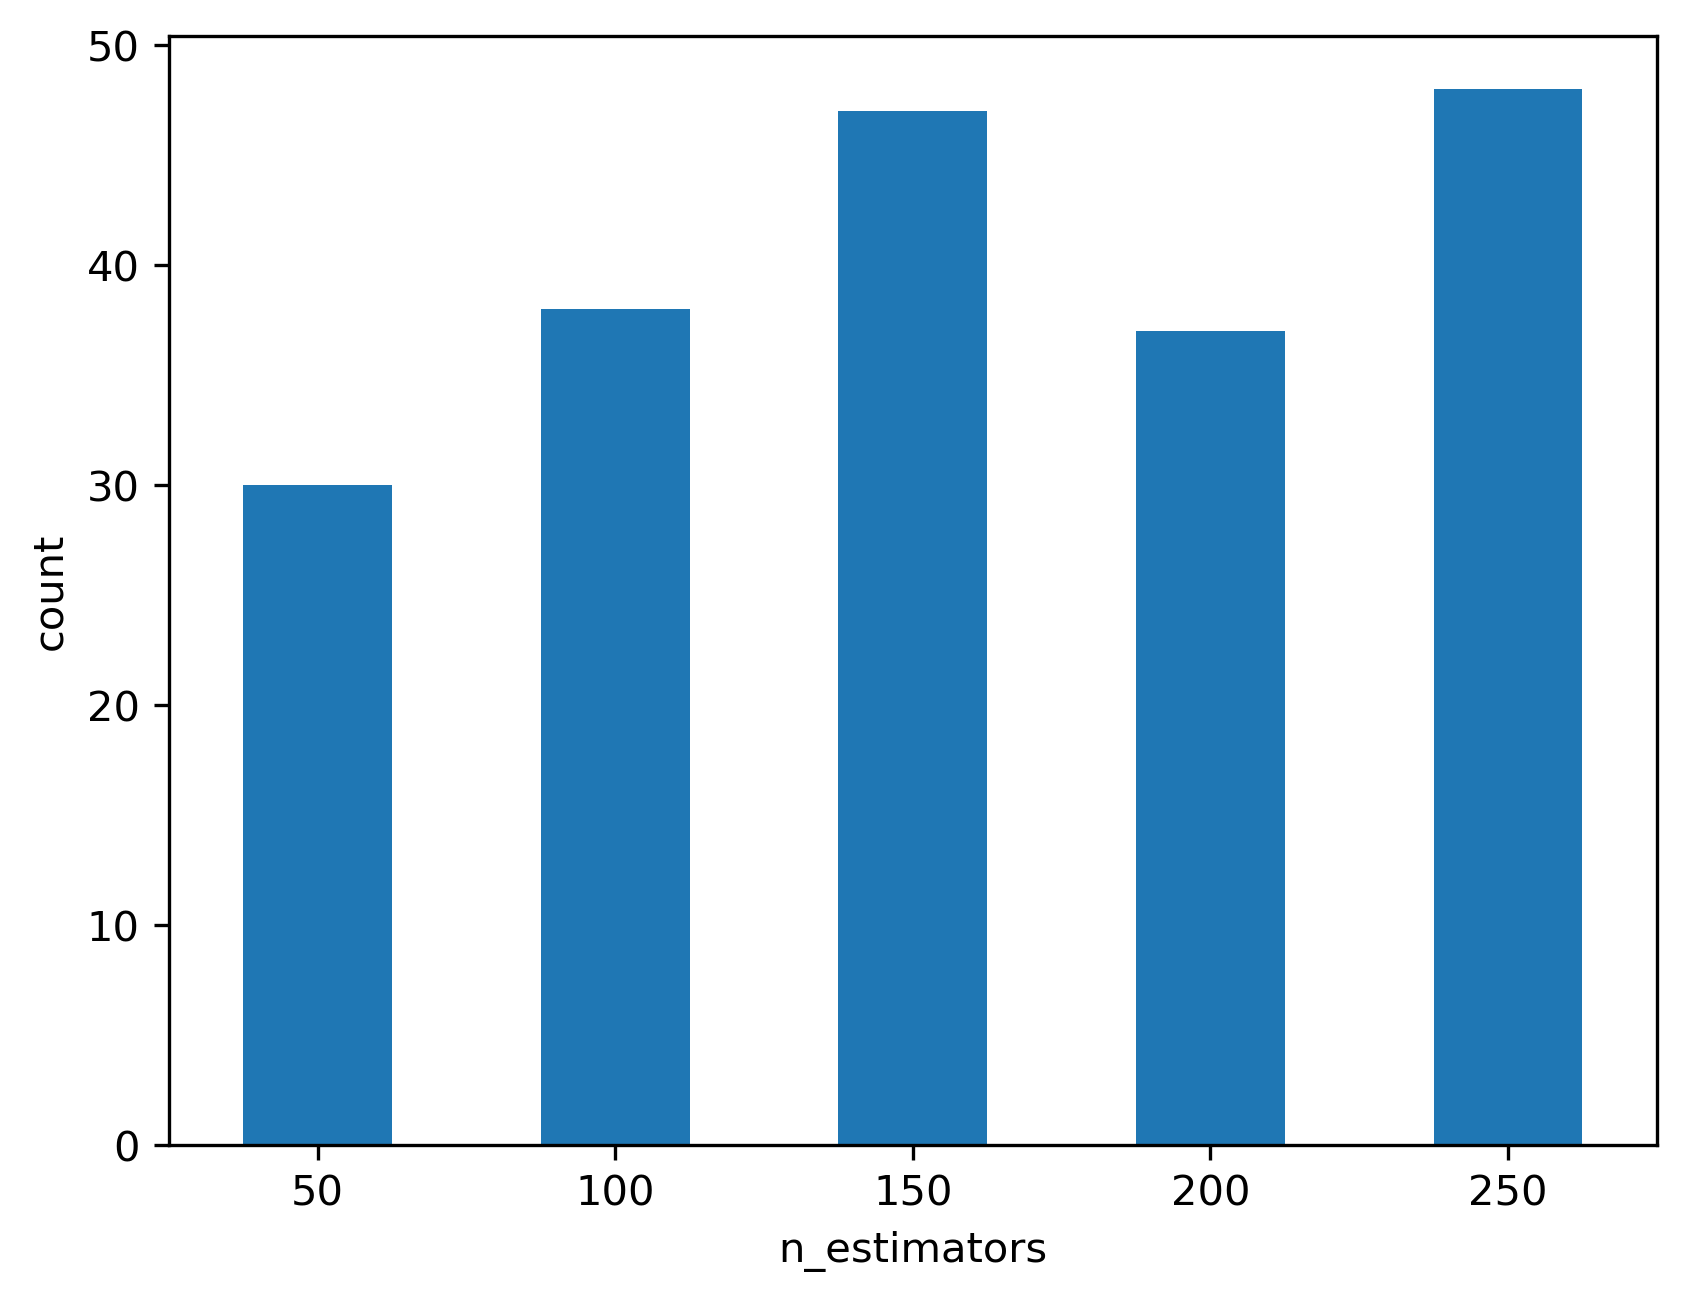

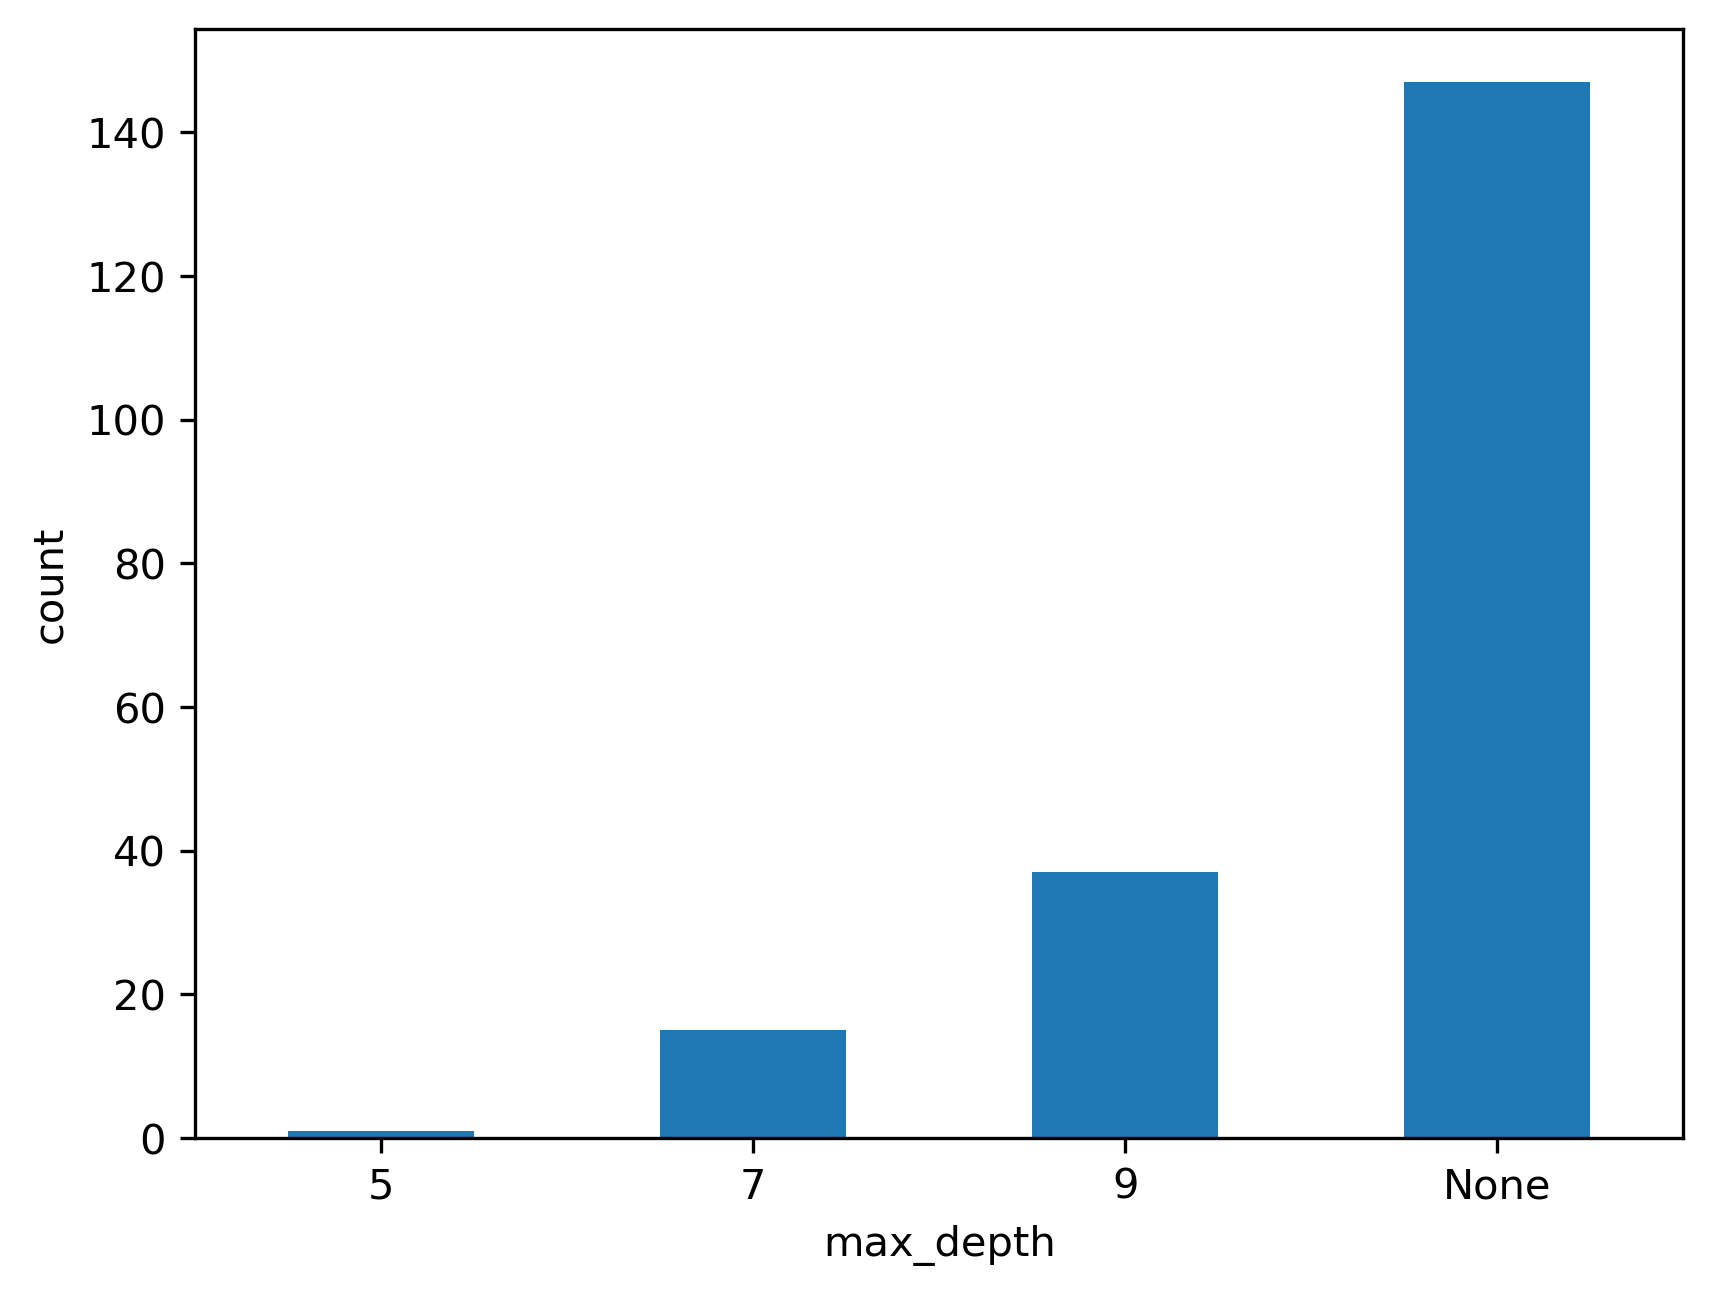

In [31]:
plt.rcParams["figure.dpi"] = 300
for col in stability_param:
    stability_param[col].value_counts().sort_index().plot(kind='bar', rot=0, ylabel='count')
    plt.show()